# Reproduce Prof's AWK script output in Python

In [2]:
import numpy as np
from Bio.PDB import PDBParser
import pandas as pd
import mdtraj as md
import nglview as nv
import seaborn as sns
import matplotlib.pyplot as plt

### Explore PDB file and structure

In [61]:
pd.set_option('display.max_rows', 10000)

In [87]:
pdb_o1f2 = md.load(path_o1f2)
pdb_o1f2_df, _ = pdb_o1f2.topology.to_dataframe()
display(pdb_o1f2_df)

,serial,name,element,resSeq,resName,chainID,segmentID
0,1,N,N,1,GLY,0,
1,2,H,H,1,GLY,0,
2,3,H2,H,1,GLY,0,
3,4,H3,H,1,GLY,0,
4,5,CA,C,1,GLY,0,
5,6,HA2,H,1,GLY,0,
6,7,HA3,H,1,GLY,0,
7,8,C,C,1,GLY,0,
8,9,O,O,1,GLY,0,
9,10,N,N,2,SER,0,


In [103]:
print(_)

[[4.000e+00 7.000e+00 0.000e+00 0.000e+00]
 [7.000e+00 8.000e+00 0.000e+00 0.000e+00]
 [4.000e+00 5.000e+00 0.000e+00 0.000e+00]
 ...
 [6.118e+03 6.121e+03 0.000e+00 0.000e+00]
 [6.112e+03 6.113e+03 0.000e+00 0.000e+00]
 [6.105e+03 6.106e+03 0.000e+00 0.000e+00]]


In [88]:
view = nv.show_mdtraj(pdb_o1f2)
view

NGLWidget()

In [83]:
num_atom_chain1 = pdb_o1f2_df.query('chainID == 0').shape[0]
num_atom_chain2 = pdb_o1f2_df.query('chainID == 1').shape[0]
print(num_atom_chain1, num_atom_chain2)

4343 1640


In [85]:
res_num_chain1 = pdb_o1f2_df.query('chainID == 0').resSeq.unique()
res_num_chain2 = pdb_o1f2_df.query('chainID == 1').resSeq.unique()
print(res_num_chain1, res_num_chain2, sep='\n')

[  1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17  18
  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35  36
  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53  54
  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71  72
  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89  90
  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107 108
 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125 126
 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143 144
 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161 162
 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179 180
 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197 198
 199 200 201 202 203 204 205 206 207 208 209 210 211 212 213 214 215 216
 217 218 219 220 221 222 223 224 225 226 227 228 229 230 231 232 233 234
 235 236 237 238 239 240 241 242 243 244 245 246 24

#### Get atomic coordinates for interface visualization
WRONG

In [100]:
pdb_o1f2.xyz

array([[[5.3337, 3.5532, 5.7943],
        [5.2849, 3.6131, 5.7292],
        [5.2658, 3.4998, 5.8466],
        ...,
        [3.1008, 6.5637, 6.1044],
        [2.9825, 6.5879, 6.1352],
        [3.1886, 6.6507, 6.1087]]], dtype=float32)

In [89]:
atom_xyz_chain1 = pdb_o1f2.xyz[:,:num_atom_chain1][0]
atom_xyz_chain2 = pdb_o1f2.xyz[:,-num_atom_chain2:][0]
print(atom_xyz_chain1, atom_xyz_chain2, sep='\n')

[[5.3337 3.5532 5.7943]
 [5.2849 3.6131 5.7292]
 [5.2658 3.4998 5.8466]
 ...
 [7.0422 2.971  2.7285]
 [6.9583 2.9907 2.6375]
 [7.161  2.9384 2.7029]]
[[4.2423 5.1623 3.0974]
 [4.1757 5.0829 3.0635]
 [4.1898 5.2568 3.1113]
 ...
 [3.1008 6.5637 6.1044]
 [2.9825 6.5879 6.1352]
 [3.1886 6.6507 6.1087]]


In [ ]:
from scipy.spatial.distance import cdist

<AxesSubplot:>

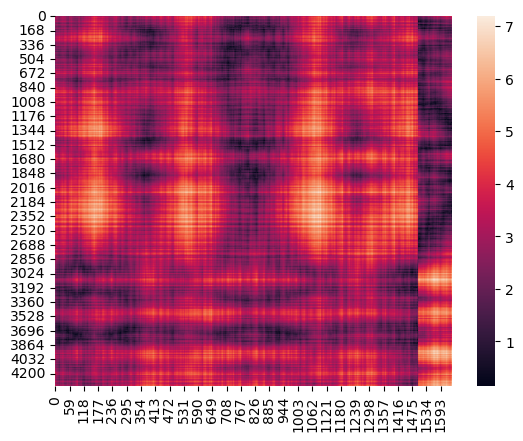

In [90]:
sns.heatmap(cdist(atom_xyz_chain1, atom_xyz_chain2))

In [91]:
cutoff = 0.5 
# boolean pair matrix specifying contact or not with 1 or 0 at the respective matrix element
interface_atom_bool = (cdist(atom_xyz_chain1, atom_xyz_chain2) < cutoff).astype(int)
print(interface_atom_bool)

[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


In [98]:
len(interface_atom_bool)

4343

In [97]:
interface_atom_bool[1]

array([0, 0, 0, ..., 0, 0, 0])

In [99]:
len(interface_atom_bool[1])

1640

In [92]:
int_atom_c1, int_atom_c2 = np.where(interface_atom_bool == 1)
print(int_atom_c1, int_atom_c2, sep='\n')

[  55   55   56 ... 3848 3848 3848]
[1499 1501 1499 ... 1483 1492 1497]


In [94]:
int_atom_uniq_c1 = np.unique(int_atom_c1) + 1
int_atom_uniq_c2 = np.unique(int_atom_c2) + num_atom_chain1
print(int_atom_uniq_c1, int_atom_uniq_c2, sep='\n')

[  56   57   58   59   60   61   62   63   78   79   80   81   82   92
   93   94   95   96   97   98   99  100  101  102  103  104  105  106
  107  108  113  114  115  116  117  118  119  120  121  122  123  124
  125  126  127  128  129  130  131  132  133  134  135  136  140  141
  142  143  144  145  146  147  148  149  150  151  152  153  154  155
  156  157  158  159  160  161  162  163  164  180  181  182  183  184
  186  187  188  189  329  353  354  356  357  358  359  360  361  362
  363  364  365  366  367  368  369  370  372  376  377  379  380  382
  383  384  385  386  387  388  389  390  391  392  393  394  396  401
  411  412  413  414  415  416  417  418  419  420  421  422  486  487
  488  489  490  491  492  493  506  507  508  509  510  511  527  528
  534  535  536  537  538  539  540  541  542  543  544  545  546  547
  548  551  552  553  557  581  585  688  693  694  695  696  697  736
  737  738  739  740  742  743  744  745  746  911  912  913  914  915
  916 

In [101]:
int_res_c1 = pdb_o1f2_df.loc[int_atom_uniq_c1,:].resSeq.unique()
int_res_c2 = pdb_o1f2_df.loc[int_atom_uniq_c2,:].resSeq.unique()
print(int_res_c1, int_res_c2, sep='\n')

[  5   6   7   8   9  10  11  12  21  23  24  25  26  27  32  33  34  35
  36  37  45  48  59  63  64  65  66  67  69  70  71  72  73  74  76  77
  78  80  81  84  94  95  96  97  98  99 111 113 114 115 116 117 118 119
 120 121 122 123 124 125 140 142 143 144 146 147 150 152 153 155 156 159
 163 164 167 168 171 188 190 192 202 204 206 207 229 231 232 233 234 235
 236 237 238 240 242 244]
[276 277 278 279 280 281 282 288 290 291 292 293 295 297 298 299 300 319
 320 321 322 323 324 325 326 327 328 329 330 331 333 334 335 336 366 367
 368 369 370 371 372 373 374 375]


In [102]:
view1 = nv.show_mdtraj(pdb_o1f2)
# Iterate over the residues in the arrays A_ires and B_ires 
for res in np.concatenate([int_res_c1, int_res_c2]):
    # For each residue, add a ball-and-stick representation
    view1.add_ball_and_stick(selection=str(res),opacity=1,aspectRatio=1)
view1

NGLWidget()

WRONG

SOME NON-interface residues are also shown with ball-and-stick

### Explore Biopython PDB data structure
NOTE: input PDB file should have NO chain info\
i.e., `tleap`: `parm7` + `rst7` $\rightarrow$ `cpptraj`: `pdb` (lost chain info)

In [18]:
path_o1f2 = '/home/wjoon21/project/a02int/o1f2.pdb'

In [22]:
pdbparser = PDBParser(QUIET=True)
structure_o1f2 = pdbparser.get_structure('PDB', path_o1f2)

In [17]:
# Iterate over all models in the structure
for model in structure_o1f2:
    print(f"Model: {model.id}")
    
    # Iterate over all chains in the model
    for chain in model:
        print(f"Chain: {chain.id}")
        
        # Iterate over all residues in the chain
        for residue in chain:
            print(f"Residue: {residue.resname} {residue.id[1]}")
            
            # Iterate over all atoms in the residue
            for atom in residue:
                print(f"Atom: {atom.name} {atom.coord}")

Model: 0
Chain:  
Residue: GLY 1
Atom: N [53.337 35.532 57.943]
Atom: H1 [52.849 36.131 57.292]
Atom: H2 [52.658 34.998 58.466]
Atom: H3 [53.968 34.952 57.409]
Atom: CA [54.07  36.311 58.955]
Atom: HA2 [54.621 35.665 59.639]
Atom: HA3 [54.791 36.979 58.484]
Atom: C [53.051 37.064 59.767]
Atom: O [52.231 36.436 60.434]
Residue: SER 2
Atom: N [53.07  38.397 59.665]
Atom: H [53.772 38.834 59.085]
Atom: CA [51.959 39.28  60.097]
Atom: HA [51.764 39.161 61.163]
Atom: CB [52.319 40.754 59.813]
Atom: HB2 [52.379 40.83  58.727]
Atom: HB3 [51.51  41.389 60.172]
Atom: OG [53.52  41.165 60.422]
Atom: HG [53.717 42.047 60.098]
Atom: C [50.612 38.954 59.415]
Atom: O [50.624 38.42  58.314]
Residue: HIE 3
Atom: N [49.466 39.38  60.005]
Atom: H [49.515 39.761 60.94 ]
Atom: CA [48.094 39.329 59.414]
Atom: HA [48.18  39.193 58.336]
Atom: CB [47.339 38.112 59.99 ]
Atom: HB2 [47.232 38.239 61.067]
Atom: HB3 [46.366 38.083 59.499]
Atom: CG [47.961 36.739 59.765]
Atom: ND1 [47.424 35.799 58.873]
Atom: CE1 [

In [35]:
structure_o1f2

<Structure id=PDB>

In [58]:
a, xa, b, xb = [], [], [], []
for atom_o1f2 in structure_o1f2.get_atoms():
    if atom_o1f2.get_name() != "H" and atom_o1f2.get_name() not in ["C", "N", "O"]:
        res_seq = atom_o1f2.get_parent().get_id()[1]
        print(f"Residue sequence number: {res_seq}")
        # if the residue is found in the first chain
        if 1 <= res_seq <= 275:
            a.append(atom_o1f2.get_serial_number())
            xa.append(atom_o1f2.get_coord())
        # if the residue is found in the second chain
        elif 276 <= res_seq <= 375:
            b.append(atom_o1f2.get_serial_number())
            xb.append(atom_o1f2.get_coord())

xaArray, xbArray = np.array(xa), np.array(xb)

Residue sequence number: 1
Residue sequence number: 1
Residue sequence number: 1
Residue sequence number: 1
Residue sequence number: 1
Residue sequence number: 1
Residue sequence number: 2
Residue sequence number: 2
Residue sequence number: 2
Residue sequence number: 2
Residue sequence number: 2
Residue sequence number: 2
Residue sequence number: 2
Residue sequence number: 3
Residue sequence number: 3
Residue sequence number: 3
Residue sequence number: 3
Residue sequence number: 3
Residue sequence number: 3
Residue sequence number: 3
Residue sequence number: 3
Residue sequence number: 3
Residue sequence number: 3
Residue sequence number: 3
Residue sequence number: 3
Residue sequence number: 3
Residue sequence number: 4
Residue sequence number: 4
Residue sequence number: 4
Residue sequence number: 4
Residue sequence number: 4
Residue sequence number: 4
Residue sequence number: 4
Residue sequence number: 5
Residue sequence number: 5
Residue sequence number: 5
Residue sequence number: 5
R

$\rightarrow$ Residue index in `if` statement should start from 1, i.e., same as `pdb` file indexing\
NOT 0-indexing (was confused with Python syntax)

NOTE: output ends at `Residue sequence number: 385` (last residue in the third chain)\
because `print()` is before the nested `if` statement with residue index boundaries

In [46]:
print(a, xaArray, sep='\n')

[2, 3, 4, 5, 6, 7, 12, 13, 14, 15, 16, 17, 18, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 40, 41, 42, 43, 44, 45, 46, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 167, 168, 169, 170, 171, 172, 173, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 194, 195, 196, 197, 198, 199, 200, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 216, 217, 218, 219, 220, 221, 222, 223, 224, 228, 229, 230, 231, 232, 233, 234, 235, 236, 237, 238, 243, 244, 245, 250, 251, 252, 253, 254, 255, 256, 257, 258, 259, 260, 261, 262, 263, 264, 265, 266, 267, 268, 269, 274, 275, 276, 281, 282, 283, 284, 285, 286, 287, 288,

In [42]:
print(b, xbArray, sep='\n')

[4345, 4346, 4347, 4348, 4349, 4350, 4351, 4352, 4353, 4354, 4355, 4356, 4357, 4358, 4359, 4360, 4365, 4366, 4367, 4368, 4369, 4370, 4371, 4372, 4373, 4374, 4375, 4376, 4377, 4378, 4379, 4384, 4385, 4386, 4387, 4388, 4389, 4390, 4391, 4392, 4393, 4394, 4395, 4396, 4401, 4402, 4403, 4404, 4405, 4406, 4407, 4408, 4409, 4410, 4411, 4412, 4413, 4414, 4415, 4416, 4417, 4418, 4419, 4420, 4425, 4426, 4427, 4428, 4429, 4430, 4431, 4432, 4433, 4434, 4438, 4439, 4440, 4441, 4442, 4443, 4444, 4445, 4446, 4447, 4448, 4453, 4454, 4455, 4456, 4457, 4458, 4459, 4460, 4461, 4462, 4463, 4464, 4465, 4466, 4467, 4468, 4469, 4470, 4475, 4476, 4477, 4478, 4479, 4480, 4481, 4482, 4483, 4484, 4485, 4486, 4487, 4488, 4489, 4494, 4495, 4496, 4497, 4498, 4499, 4500, 4501, 4502, 4503, 4504, 4505, 4506, 4511, 4512, 4513, 4514, 4515, 4516, 4517, 4518, 4519, 4520, 4521, 4522, 4527, 4528, 4529, 4530, 4531, 4532, 4533, 4534, 4535, 4536, 4537, 4538, 4539, 4540, 4541, 4542, 4543, 4548, 4549, 4550, 4551, 4552, 4553, 455

### `interface_nonH_rev.awk`
Consider ONLY the non-hydrogen atoms

#### Interpret AWK script

Original `interfaceH.awk`
```awk
BEGIN{k=0;i=0;l=0;m=0;dd=16.0;max=0}
{if($1 == "ATOM" && match($3,"H") != 1 && $5 >= va1 && $5 <= va2) {a[k++]=$2;xa[i++]=$6;xa[i++]=$7;xa[i++]=$8};
if ($1 == "ATOM" && match($3,"H") != 1 && $5 >= va3 && $5 <= va4) {b[l++]=$2;xb[m++]=$6;xb[m++]=$7;xb[m++]=$8}}
END{ for(n=0;n<k;n++) {for(j=0;j<l;j++) {d=(xa[3*n]-xb[3*j])**2+(xa[3*n+1]-xb[3*j+1])**2+(xa[3*n+2]-xb[3*j+2])**2;
	if(d < dd) {ima[n]=1;imb[j]=1}}};
       for(n=0;n<k;n++) if(ima[n] == 1) {printf("%3d%1s",a[n],",");max++};
       for(j=0;j<l;j++) if(imb[j] == 1) {printf("%3d%1s",b[j],",");max++};
       printf("\n"); print max;
       for(n=0;n<k;n++) if(ima[n] == 1) printf("%7.3f%1s%7.3f%1s%7.3f%1s",xa[3*n],",",xa[3*n+1],",",xa[3*n+2],",");
       for(j=0;j<l;j++) if(imb[j] == 1) printf("%7.3f%1s%7.3f%1s%7.3f%1s",xb[3*j],",",xb[3*j+1],",",xb[3*j+2],",");
       printf("\n")}
```
[SYNTAX ERROR] Exponentiation should be `^` (AWK), NOT `**` (Python)

Revised:
```awk
BEGIN{k=0;i=0;l=0;m=0;dd=16.0;max=0}
{if($1 == "ATOM" && match($3,"H") != 1 && $5 >= va1 && $5 <= va2) {a[k++]=$2;xa[i++]=$6;xa[i++]=$7;xa[i++]=$8};
if ($1 == "ATOM" && match($3,"H") != 1 && $5 >= va3 && $5 <= va4) {b[l++]=$2;xb[m++]=$6;xb[m++]=$7;xb[m++]=$8}}
END{ for(n=0;n<k;n++) {for(j=0;j<l;j++) {d=(xa[3*n]-xb[3*j])^2+(xa[3*n+1]-xb[3*j+1])^2+(xa[3*n+2]-xb[3*j+2])^2;
    if(d < dd) {ima[n]=1;imb[j]=1}}};
       for(n=0;n<k;n++) if(ima[n] == 1) {printf("%3d%1s",a[n],",");max++};
       for(j=0;j<l;j++) if(imb[j] == 1) {printf("%3d%1s",b[j],",");max++};
       printf("\n"); print max;
       for(n=0;n<k;n++) if(ima[n] == 1) printf("%7.3f%1s%7.3f%1s%7.3f%1s",xa[3*n],",",xa[3*n+1],",",xa[3*n+2],",");
       for(j=0;j<l;j++) if(imb[j] == 1) printf("%7.3f%1s%7.3f%1s%7.3f%1s",xb[3*j],",",xb[3*j+1],",",xb[3*j+2],",");
       printf("\n")}
```

This AWK script processes a PDB (Protein Data Bank) file, which is a standard format for storing 3D structural data of molecules, especially proteins and nucleic acids. The script identifies "interacting" atoms based on their distances from each other.

Here's a line-by-line explanation:

```plaintext
BEGIN{k=0;i=0;l=0;m=0;dd=16.0;max=0}
```
This block is executed once at the beginning. It initializes several variables: `k`, `i`, `l`, `m` are counters, `dd` is the distance threshold for determining whether atoms interact, and `max` is a counter for the number of interacting atoms.

```plaintext
{if($1 == "ATOM" && match($3,"H") != 1 && $5 >= va1 && $5 <= va2) {a[k++]=$2;xa[i++]=$6;xa[i++]=$7;xa[i++]=$8};
```
This block is executed for each line in the input file. If the line (1) describes an atom (first entry is "`ATOM`"), (2) ~~(not a hydrogen atom)~~ third entry does NOT start with "`H`", and (3) its residue sequence number is within the range `va1` to `va2`, the atom's serial number is stored in array `a` and its coordinates are stored in array `xa`.

```plaintext
if ($1 == "ATOM" && match($3,"H") != 1 && $5 >= va3 && $5 <= va4) {b[l++]=$2;xb[m++]=$6;xb[m++]=$7;xb[m++]=$8}}
```
Similarly, if the atom's residue sequence number is within the range `va3` to `va4`, the atom's serial number is stored in array `b` and its coordinates are stored in array `xb`.

```plaintext
END{ for(n=0;n<k;n++) {for(j=0;j<l;j++) {d=(xa[3*n]-xb[3*j])^2+(xa[3*n+1]-xb[3*j+1])^2+(xa[3*n+2]-xb[3*j+2])^2;
    if(d < dd) {ima[n]=1;imb[j]=1}}};
```
This block is executed once at the end. It calculates the squared Euclidean distance between each pair of atoms from the two groups. If the distance is less than `dd`, the atoms are marked as "interacting" by setting `ima[n]` and `imb[j]` to 1.

```plaintext
for(n=0;n<k;n++) if(ima[n] == 1) {printf("%3d%1s",a[n],",");max++};
```
This line prints the serial numbers of all interacting atoms from the first group, separated by commas. It also increments the `max` counter for each interacting atom.

```plaintext
for(j=0;j<l;j++) if(imb[j] == 1) {printf("%3d%1s",b[j],",");max++};
```
Similarly, this line prints the serial numbers of all interacting atoms from the second group, and increments the `max` counter.

```plaintext
printf("\n"); print max;
```
This line prints a newline character, followed by the total number of interacting atoms.

```plaintext
for(n=0;n<k;n++) if(ima[n] == 1) printf("%7.3f%1s%7.3f%1s%7.3f%1s",xa[3*n],",",xa[3*n+1],",",xa[3*n+2],",");
```
This line prints the coordinates of all interacting atoms from the first group, separated by commas.

```plaintext
for(j=0;j<l;j++) if(imb[j] == 1) printf("%7.3f%1s%7.3f%1s%7.3f%1s",xb[3*j],",",xb[3*j+1],",",xb[3*j+2],",");
```
Similarly, this line prints the coordinates of all interacting atoms from the second group.

```plaintext
printf("\n")}
```
Finally, this line prints a newline character at the end.

Please note that the variables `va1`, `va2`, `va3`, and `va4` are not defined in the script, so they should be passed as command-line arguments when running the script.

NOTE:
```awk
match($3,"H") != 1
```
in AWK means
```python
not startswith("H")
```
in Python

GitHub Copilot gave WRONG explanation!\
FIXED in explanation above and functions below

Terminal command:
```sh
awk -v va1=1 -v va2=275 -v va3=276 -v va4=375 -f interfaceH_rev.awk o1f2.pdb > interface_nonH_o1f2.txt
```
Output:
```txt
115,118,119,121,123,125,127,155,157,161,186,358,387,391,414,416,417,489,491,536,539,542,545,547,551,1456,1458,1462,1489,1492,1493,1494,1522,1796,1807,1809,1834,1863,1865,1868,1869,1871,1872,1873,1875,1879,1884,1890,1909,1910,3005,3007,3011,3041,3043,3183,3186,3188,3192,3220,3222,3224,3640,3642,3646,3652,3654,3656,3659,3662,3663,3664,3665,3666,3679,3680,3683,3685,3688,3691,3694,3696,3697,3700,3705,3706,3709,3712,3715,3717,3718,3719,3721,3723,3727,3728,3729,3731,3734,3735,3736,3738,3740,3743,3744,3745,3799,3800,3801,3836,3838,3841,4344,4348,4350,4356,4369,4376,4415,4461,4464,4467,4502,4503,4504,4529,4532,4533,4535,4537,4538,4540,4542,4555,4556,4559,4561,4564,4567,4570,4572,4573,4576,4579,4580,4590,4592,4751,4753,4772,4775,4776,4778,4781,4783,4785,4809,4812,4852,4854,4856,4867,4881,5198,5201,5202,5203,5205,5206,5210,5213,5219,5224,5229,5232,5236,5240,5243,5248,5250,5252,5254,5255,5305,5308,5309,5311,5313,5314,5316,5320,5322,5323,5324,5346,5348,5366,5368,5369,5400,5403,5405,5409,5953,5956,5962,5964,5965,5966,5968,5973,5976,5977,5981,5982,5983,
216
 37,000, 49,000, 52,000, 38,000, 49,000, 52,000, 38,000, 47,000, 52,000, 40,000, 47,000, 52,000, 41,000, 48,000, 52,000, 40,000, 49,000, 51,000, 39,000, 49,000, 51,000, 32,000, 53,000, 48,000, 32,000, 55,000, 47,000, 34,000, 53,000, 48,000, 30,000, 57,000, 45,000, 30,000, 48,000, 47,000, 33,000, 45,000, 49,000, 35,000, 46,000, 50,000, 38,000, 44,000, 50,000, 39,000, 43,000, 49,000, 38,000, 44,000, 47,000, 34,000, 41,000, 48,000, 33,000, 41,000, 48,000, 30,000, 42,000, 49,000, 29,000, 41,000, 49,000, 27,000, 42,000, 48,000, 28,000, 42,000, 47,000, 27,000, 43,000, 46,000, 27,000, 43,000, 45,000, 33,000, 60,000, 45,000, 33,000, 58,000, 46,000, 32,000, 60,000, 44,000, 36,000, 56,000, 49,000, 37,000, 57,000, 48,000, 37,000, 58,000, 48,000, 38,000, 56,000, 48,000, 36,000, 53,000, 54,000, 42,000, 56,000, 57,000, 39,000, 57,000, 57,000, 39,000, 58,000, 57,000, 39,000, 60,000, 51,000, 36,000, 63,000, 47,000, 35,000, 64,000, 46,000, 34,000, 64,000, 46,000, 34,000, 66,000, 45,000, 37,000, 63,000, 47,000, 38,000, 63,000, 46,000, 38,000, 61,000, 47,000, 39,000, 61,000, 47,000, 41,000, 61,000, 47,000, 41,000, 65,000, 49,000, 43,000, 65,000, 47,000, 45,000, 62,000, 53,000, 45,000, 61,000, 52,000, 58,000, 34,000, 27,000, 57,000, 33,000, 28,000, 57,000, 35,000, 28,000, 57,000, 37,000, 25,000, 57,000, 38,000, 26,000, 56,000, 40,000, 30,000, 56,000, 41,000, 30,000, 56,000, 42,000, 28,000, 55,000, 41,000, 27,000, 54,000, 37,000, 30,000, 52,000, 37,000, 31,000, 52,000, 37,000, 32,000, 52,000, 45,000, 35,000, 52,000, 45,000, 34,000, 52,000, 43,000, 36,000, 51,000, 46,000, 38,000, 51,000, 46,000, 39,000, 49,000, 47,000, 39,000, 49,000, 47,000, 40,000, 48,000, 48,000, 40,000, 48,000, 49,000, 41,000, 47,000, 49,000, 39,000, 50,000, 45,000, 39,000, 50,000, 44,000, 38,000, 48,000, 43,000, 40,000, 47,000, 44,000, 41,000, 46,000, 42,000, 39,000, 46,000, 42,000, 38,000, 47,000, 41,000, 37,000, 48,000, 41,000, 36,000, 48,000, 40,000, 35,000, 48,000, 40,000, 34,000, 49,000, 41,000, 33,000, 49,000, 39,000, 33,000, 44,000, 40,000, 40,000, 44,000, 42,000, 40,000, 42,000, 41,000, 41,000, 42,000, 40,000, 41,000, 44,000, 39,000, 40,000, 43,000, 38,000, 39,000, 42,000, 39,000, 38,000, 43,000, 37,000, 39,000, 43,000, 36,000, 38,000, 44,000, 35,000, 39,000, 41,000, 36,000, 39,000, 41,000, 35,000, 38,000, 41,000, 36,000, 40,000, 39,000, 36,000, 40,000, 39,000, 35,000, 41,000, 38,000, 34,000, 41,000, 40,000, 34,000, 41,000, 40,000, 32,000, 41,000, 40,000, 31,000, 41,000, 42,000, 31,000, 40,000, 42,000, 32,000, 41,000, 42,000, 30,000, 40,000, 47,000, 36,000, 36,000, 47,000, 37,000, 35,000, 47,000, 35,000, 35,000, 53,000, 40,000, 33,000, 53,000, 41,000, 32,000, 54,000, 43,000, 31,000, 36,000, 66,000, 44,000, 37,000, 67,000, 44,000, 37,000, 67,000, 46,000, 39,000, 68,000, 48,000, 42,000, 66,000, 44,000, 40,000, 63,000, 44,000, 42,000, 59,000, 45,000, 48,000, 52,000, 38,000, 47,000, 52,000, 39,000, 47,000, 52,000, 41,000, 48,000, 45,000, 35,000, 49,000, 44,000, 35,000, 48,000, 45,000, 37,000, 46,000, 39,000, 32,000, 45,000, 40,000, 33,000, 45,000, 41,000, 34,000, 44,000, 41,000, 35,000, 44,000, 40,000, 36,000, 43,000, 41,000, 37,000, 44,000, 39,000, 36,000, 45,000, 39,000, 34,000, 44,000, 35,000, 33,000, 45,000, 35,000, 33,000, 43,000, 34,000, 35,000, 42,000, 33,000, 36,000, 42,000, 32,000, 37,000, 41,000, 32,000, 37,000, 40,000, 33,000, 38,000, 38,000, 32,000, 38,000, 38,000, 31,000, 38,000, 37,000, 33,000, 38,000, 44,000, 33,000, 35,000, 45,000, 33,000, 36,000, 43,000, 29,000, 37,000, 42,000, 29,000, 37,000, 41,000, 38,000, 35,000, 41,000, 38,000, 36,000, 43,000, 44,000, 37,000, 43,000, 45,000, 38,000, 42,000, 45,000, 39,000, 42,000, 45,000, 41,000, 44,000, 46,000, 42,000, 44,000, 46,000, 40,000, 44,000, 45,000, 39,000, 44,000, 50,000, 40,000, 45,000, 50,000, 39,000, 37,000, 60,000, 45,000, 37,000, 59,000, 45,000, 38,000, 59,000, 44,000, 34,000, 60,000, 42,000, 32,000, 55,000, 43,000, 32,000, 44,000, 46,000, 31,000, 43,000, 46,000, 30,000, 43,000, 46,000, 31,000, 42,000, 47,000, 35,000, 45,000, 45,000, 33,000, 47,000, 45,000, 33,000, 49,000, 45,000, 34,000, 51,000, 45,000, 33,000, 52,000, 45,000, 34,000, 48,000, 47,000, 38,000, 47,000, 48,000, 39,000, 48,000, 49,000, 39,000, 50,000, 48,000, 39,000, 53,000, 48,000, 39,000, 53,000, 49,000, 38,000, 53,000, 51,000, 37,000, 53,000, 50,000, 37,000, 53,000, 49,000, 41,000, 51,000, 48,000, 42,000, 50,000, 49,000, 41,000, 58,000, 49,000, 42,000, 58,000, 50,000, 43,000, 59,000, 50,000, 43,000, 59,000, 52,000, 42,000, 58,000, 52,000, 42,000, 58,000, 54,000, 41,000, 57,000, 54,000, 40,000, 57,000, 52,000, 41,000, 58,000, 51,000, 41,000, 56,000, 47,000, 40,000, 56,000, 46,000, 36,000, 54,000, 46,000, 35,000, 55,000, 45,000, 40,000, 46,000, 45,000, 41,000, 46,000, 46,000, 41,000, 46,000, 48,000, 39,000, 42,000, 39,000, 39,000, 41,000, 38,000, 40,000, 41,000, 38,000, 39,000, 40,000, 39,000, 50,000, 36,000, 28,000, 52,000, 37,000, 27,000, 55,000, 35,000, 26,000, 52,000, 38,000, 28,000, 54,000, 39,000, 28,000, 51,000, 39,000, 28,000, 51,000, 40,000, 29,000, 52,000, 42,000, 27,000, 52,000, 43,000, 27,000, 52,000, 44,000, 28,000, 50,000, 40,000, 30,000, 50,000, 39,000, 31,000, 50,000, 41,000, 31,000,
```
First line: interacting atom indices\
Second line: number of interacting atoms\
Third line: coordinates (x, y, z) of interacting atoms

AWK:
1. outputs " `,` " as decimal points... $\rightarrow$ change Linux system locale???
2. truncates the atomic coordinates in the input `pdb` to the nearest integer before calculating???

Store interacting atoms' indices for comparison with Python function output

In [138]:
awk_int_atom_nonH = [115,118,119,121,123,125,127,155,157,161,
                     186,358,387,391,414,416,417,489,491,536,
                     539,542,545,547,551,1456,1458,1462,1489,
                     1492,1493,1494,1522,1796,1807,1809,1834,
                     1863,1865,1868,1869,1871,1872,1873,1875,
                     1879,1884,1890,1909,1910,3005,3007,3011,
                     3041,3043,3183,3186,3188,3192,3220,3222,
                     3224,3640,3642,3646,3652,3654,3656,3659,
                     3662,3663,3664,3665,3666,3679,3680,3683,
                     3685,3688,3691,3694,3696,3697,3700,3705,
                     3706,3709,3712,3715,3717,3718,3719,3721,
                     3723,3727,3728,3729,3731,3734,3735,3736,
                     3738,3740,3743,3744,3745,3799,3800,3801,
                     3836,3838,3841,4344,4348,4350,4356,4369,
                     4376,4415,4461,4464,4467,4502,4503,4504,
                     4529,4532,4533,4535,4537,4538,4540,4542,
                     4555,4556,4559,4561,4564,4567,4570,4572,
                     4573,4576,4579,4580,4590,4592,4751,4753,
                     4772,4775,4776,4778,4781,4783,4785,4809,
                     4812,4852,4854,4856,4867,4881,5198,5201,
                     5202,5203,5205,5206,5210,5213,5219,5224,
                     5229,5232,5236,5240,5243,5248,5250,5252,
                     5254,5255,5305,5308,5309,5311,5313,5314,
                     5316,5320,5322,5323,5324,5346,5348,5366,
                     5368,5369,5400,5403,5405,5409,5953,5956,
                     5962,5964,5965,5966,5968,5973,5976,5977,
                     5981,5982,5983]
print(len(interacting_atom_index))

216


#### Translate to Python

##### WRONG

In [68]:
def interface_nonH_pdb1(structure, va1, va2, va3, va4, dd=16.0):
    # Initialize lists and dictionaries
    a, xa, b, xb = [], [], [], []
    ima, imb = {}, {}

    # Loop over all atoms in the structure
    for atom in structure.get_atoms():
        # If the atom is not a hydrogen atom
        if atom.get_name() != "H":
            # Get the residue sequence number of the atom
            res_seq = atom.get_parent().get_id()[1]
            # If the residue sequence number is within the range va1 to va2
            if va1 <= res_seq <= va2:
                # Append the atom's serial number to list a and its coordinates to list xa
                a.append(atom.get_serial_number())
                xa.append(atom.get_coord())
            # If the residue sequence number is within the range va3 to va4
            elif va3 <= res_seq <= va4:
                # Append the atom's serial number to list b and its coordinates to list xb
                b.append(atom.get_serial_number())
                xb.append(atom.get_coord())

    # Convert lists xa and xb to numpy arrays for easier manipulation
    xa, xb = np.array(xa), np.array(xb)

    # Loop over all pairs of atoms from the two groups
    for n in range(len(a)):
        for j in range(len(b)):
            # Calculate the squared Euclidean distance between the atoms
            d = np.sum((xa[n] - xb[j])**2)
            # If the distance is less than dd, mark the atoms as "interacting"
            if d < dd:
                ima[n] = 1
                imb[j] = 1

    result = []
    # Append the serial numbers of all interacting atoms from the first group
    result.append(','.join(str(a[n]) for n in range(len(a)) if ima.get(n) == 1))
    # Append the serial numbers of all interacting atoms from the second group
    result.append(','.join(str(b[j]) for j in range(len(b)) if imb.get(j) == 1))
    # Append the coordinates of all interacting atoms from the first group
    result.append(','.join(','.join(str(xa[n, k]) for k in range(3)) for n in range(len(a)) if ima.get(n) == 1))
    # Append the coordinates of all interacting atoms from the second group
    result.append(','.join(','.join(str(xb[j, k]) for k in range(3)) for j in range(len(b)) if imb.get(j) == 1))

    return result

In [69]:
interface_o1f2 = interface_nonH_pdb1(structure_o1f2, va1=1, va2=275, va3=276, va4=375)
print(interface_o1f2)

['114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,131,133,149,150,151,154,155,156,157,158,159,160,161,162,184,186,187,188,189,356,357,358,359,360,361,365,366,368,385,386,387,388,389,390,391,392,393,394,414,415,416,417,418,419,420,489,490,491,492,493,536,537,538,539,540,541,542,545,546,547,551,552,553,738,743,1342,1456,1457,1458,1459,1460,1461,1462,1463,1465,1484,1485,1486,1487,1488,1489,1490,1491,1492,1493,1494,1495,1496,1497,1498,1499,1501,1502,1521,1522,1523,1525,1526,1527,1528,1529,1530,1532,1536,1537,1741,1794,1795,1796,1797,1798,1799,1803,1807,1808,1809,1811,1812,1828,1834,1835,1836,1837,1846,1857,1858,1859,1860,1861,1863,1864,1865,1866,1867,1868,1869,1870,1871,1872,1873,1875,1876,1877,1878,1879,1880,1883,1884,1885,1887,1888,1889,1890,1891,1892,1902,1904,1905,1906,1908,1909,1910,1911,1961,3005,3006,3007,3009,3011,3012,3041,3042,3043,3044,3183,3184,3185,3186,3187,3188,3189,3190,3191,3192,3193,3194,3218,3220,3221,3222,3223,3224,3225,3250,3251,3252,3253,3613,3640,3641,364

In [75]:
def interface_nonH_pdb_explicit(structure, va1, va2, va3, va4, dd=16.0):
    a, xa, b, xb = [], [], [], []
    ima, imb = {}, {}

    for model in structure:
        for chain in model:
            for residue in chain:
                for atom in residue:
                    if atom.get_name() != "H":
                        res_seq = residue.get_id()[1]
                        if va1 <= res_seq <= va2:
                            a.append(atom.get_serial_number())
                            xa.append(atom.get_coord())
                        elif va3 <= res_seq <= va4:
                            b.append(atom.get_serial_number())
                            xb.append(atom.get_coord())

    xa, xb = np.array(xa), np.array(xb)

    for n in range(len(a)):
        for j in range(len(b)):
            d = np.sum((xa[n] - xb[j])**2)
            if d < dd:
                ima[n] = 1
                imb[j] = 1

    result = []
    result.append(','.join(str(a[n]) for n in range(len(a)) if ima.get(n) == 1))
    result.append(','.join(str(b[j]) for j in range(len(b)) if imb.get(j) == 1))
    result.append(','.join(','.join(str(xa[n, k]) for k in range(3)) for n in range(len(a)) if ima.get(n) == 1))
    result.append(','.join(','.join(str(xb[j, k]) for k in range(3)) for j in range(len(b)) if imb.get(j) == 1))

    return result

In [76]:
interface_o1f2_explicit = interface_nonH_pdb_explicit(structure_o1f2, va1=1, va2=275, va3=276, va4=375)
print(interface_o1f2_explicit)

['114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,131,133,149,150,151,154,155,156,157,158,159,160,161,162,184,186,187,188,189,356,357,358,359,360,361,365,366,368,385,386,387,388,389,390,391,392,393,394,414,415,416,417,418,419,420,489,490,491,492,493,536,537,538,539,540,541,542,545,546,547,551,552,553,738,743,1342,1456,1457,1458,1459,1460,1461,1462,1463,1465,1484,1485,1486,1487,1488,1489,1490,1491,1492,1493,1494,1495,1496,1497,1498,1499,1501,1502,1521,1522,1523,1525,1526,1527,1528,1529,1530,1532,1536,1537,1741,1794,1795,1796,1797,1798,1799,1803,1807,1808,1809,1811,1812,1828,1834,1835,1836,1837,1846,1857,1858,1859,1860,1861,1863,1864,1865,1866,1867,1868,1869,1870,1871,1872,1873,1875,1876,1877,1878,1879,1880,1883,1884,1885,1887,1888,1889,1890,1891,1892,1902,1904,1905,1906,1908,1909,1910,1911,1961,3005,3006,3007,3009,3011,3012,3041,3042,3043,3044,3183,3184,3185,3186,3187,3188,3189,3190,3191,3192,3193,3194,3218,3220,3221,3222,3223,3224,3225,3250,3251,3252,3253,3613,3640,3641,364

Check if the two function outputs are different

In [77]:
interface_o1f2_explicit == interface_o1f2

True

Was `False` (different) before due to `xa` and `xb` saving decimals as `np.float64` in the `_explicit()` function (now removed), which has a precision of 15

In [80]:
np.finfo(np.float64).precision

15

#### Functions to check list difference

In [73]:
def print_diff(list1, list2):
    set1 = set(list1)
    set2 = set(list2)

    diff = set1.symmetric_difference(set2)

    for element in diff:
        print(element)

REVISED\
better to know which elements are unique to which list

In [119]:
def diff_lists(list1, list2):
    set1 = set(list1)
    set2 = set(list2)

    only_in_list1 = list(set1.difference(set2))
    only_in_list2 = list(set2.difference(set1))

    return only_in_list1, only_in_list2

#### FIX: atom name should NOT start with, but may contain "H" elsewhere

In [165]:
def interface_nonH_pdb2(structure, va1, va2, va3, va4, dd=16.0):
    # Initialize lists and dictionaries
    a, xa, b, xb = [], [], [], []
    ima, imb = {}, {}

    # Loop over all atoms in the structure
    for atom in structure.get_atoms():
        # If the atom name does NOT start with "H"
        if not atom.get_name().startswith("H"):
            # Get the residue sequence number of the atom
            res_seq = atom.get_parent().get_id()[1]
            # If the residue sequence number is within the range va1 to va2
            if va1 <= res_seq <= va2:
                # Append the atom's serial number to list a and its coordinates to list xa
                a.append(atom.get_serial_number())
                xa.append(atom.get_coord())
            # If the residue sequence number is within the range va3 to va4
            elif va3 <= res_seq <= va4:
                # Append the atom's serial number to list b and its coordinates to list xb
                b.append(atom.get_serial_number())
                xb.append(atom.get_coord())

    # Convert lists xa and xb to numpy arrays for easier manipulation
    xa, xb = np.array(xa), np.array(xb)

    # Loop over all pairs of atoms from the two groups
    for n in range(len(a)):
        for j in range(len(b)):
            # Calculate the squared Euclidean distance between the atoms
            d = np.sum((xa[n] - xb[j])**2)
            # If the distance is less than dd, mark the atoms as "interacting"
            if d < dd:
                ima[n] = 1
                imb[j] = 1

    result = []
    # Append the serial numbers of all interacting atoms from the first group
    result.append(','.join(str(a[n]) for n in range(len(a)) if ima.get(n) == 1))
    # Append the serial numbers of all interacting atoms from the second group
    result.append(','.join(str(b[j]) for j in range(len(b)) if imb.get(j) == 1))
    # Append the coordinates of all interacting atoms from the first group
    result.append(','.join(','.join(str(xa[n, k]) for k in range(3)) for n in range(len(a)) if ima.get(n) == 1))
    # Append the coordinates of all interacting atoms from the second group
    result.append(','.join(','.join(str(xb[j, k]) for k in range(3)) for j in range(len(b)) if imb.get(j) == 1))

    return result

In [166]:
int_atom_o1f2 = interface_nonH_pdb2(structure_o1f2, va1=1, va2=275, va3=276, va4=375)
print(int_atom_o1f2)

['115,118,119,121,123,125,127,150,155,157,161,186,358,387,391,414,416,417,489,490,491,536,539,542,545,547,551,1456,1458,1462,1486,1489,1492,1493,1494,1499,1521,1522,1527,1794,1796,1807,1808,1809,1811,1828,1834,1860,1863,1865,1868,1869,1871,1872,1873,1875,1878,1879,1884,1887,1890,1902,1904,1906,1909,1910,3005,3007,3011,3041,3183,3186,3188,3189,3192,3220,3222,3224,3640,3646,3652,3654,3656,3662,3663,3664,3665,3666,3680,3683,3685,3688,3691,3694,3696,3697,3700,3703,3705,3706,3709,3715,3717,3718,3721,3723,3727,3728,3729,3731,3734,3735,3736,3738,3740,3743,3744,3745,3799,3800,3801,3836,3838,3840,3841,3843', '4344,4348,4350,4356,4357,4363,4369,4376,4414,4415,4461,4464,4467,4502,4503,4504,4529,4532,4533,4535,4537,4538,4540,4542,4555,4556,4559,4561,4564,4567,4570,4572,4573,4576,4579,4580,4589,4590,4592,4751,4752,4753,4775,4776,4778,4783,4809,4812,4850,4851,4852,4854,4856,4867,4881,5198,5201,5202,5203,5206,5210,5213,5219,5224,5229,5232,5236,5240,5243,5246,5248,5250,5252,5255,5305,5308,5309,5311,53

In [167]:
int_atom_nonH = [115,118,119,121,123,125,127,150,155,157,161,
                 186,358,387,391,414,416,417,489,490,491,536,
                 539,542,545,547,551,1456,1458,1462,1486,1489,
                 1492,1493,1494,1499,1521,1522,1527,1794,1796,
                 1807,1808,1809,1811,1828,1834,1860,1863,1865,
                 1868,1869,1871,1872,1873,1875,1878,1879,1884,
                 1887,1890,1902,1904,1906,1909,1910,3005,3007,
                 3011,3041,3183,3186,3188,3189,3192,3220,3222,
                 3224,3640,3646,3652,3654,3656,3662,3663,3664,
                 3665,3666,3680,3683,3685,3688,3691,3694,3696,
                 3697,3700,3703,3705,3706,3709,3715,3717,3718,
                 3721,3723,3727,3728,3729,3731,3734,3735,3736,
                 3738,3740,3743,3744,3745,3799,3800,3801,3836,
                 3838,3840,3841,3843,
                 4344,4348,4350,4356,4357,4363,4369,4376,4414,
                 4415,4461,4464,4467,4502,4503,4504,4529,4532,
                 4533,4535,4537,4538,4540,4542,4555,4556,4559,
                 4561,4564,4567,4570,4572,4573,4576,4579,4580,
                 4589,4590,4592,4751,4752,4753,4775,4776,4778,
                 4783,4809,4812,4850,4851,4852,4854,4856,4867,
                 4881,5198,5201,5202,5203,5206,5210,5213,5219,
                 5224,5229,5232,5236,5240,5243,5246,5248,5250,
                 5252,5255,5305,5308,5309,5311,5313,5314,5316,
                 5320,5322,5323,5324,5344,5346,5348,5350,5366,
                 5368,5369,5405,5409,5956,5958,5962,5964,5965,
                 5966,5968,5973,5977,5981,5982,5983]
print(len(int_atom_nonH))

232


Instead of a Biopython PDB structure class, import the file as it is (text)

In [176]:
def process_pdb_as_txt_nonH(file, va1, va2, va3, va4, dd=16.0):
    # Initialize lists to store atom serial numbers and coordinates
    a, xa, b, xb = [], [], [], []

    # Open the PDB file
    with open(file) as f:
        # Process each line in the file
        for line in f:
            # Split the line into fields
            fields = line.split()

            # (1) first entry is "ATOM" AND (2) third entry does NOT start with "H"
            if fields[0] == "ATOM" and not fields[2].startswith("H"):
                # Check if the residue sequence number is within the first range
                if va1 <= int(fields[4]) <= va2:
                    # Store the atom serial number and coordinates
                    a.append(int(fields[1]))
                    xa.extend([float(fields[i]) for i in range(5, 8)])

                # Check if the residue sequence number is within the second range
                elif va3 <= int(fields[4]) <= va4:
                    # Store the atom serial number and coordinates
                    b.append(int(fields[1]))
                    xb.extend([float(fields[i]) for i in range(5, 8)])

    # Convert the coordinate lists to 2D numpy arrays
    xa, xb = np.array(xa).reshape(-1, 3), np.array(xb).reshape(-1, 3)

    # Initialize boolean arrays to store which atoms are within the distance threshold
    ima, imb = np.zeros(len(a), dtype=bool), np.zeros(len(b), dtype=bool)

    # Calculate the square of the Euclidean distance between each pair of atoms
    for n in range(len(a)):
        for j in range(len(b)):
            d = np.sum((xa[n] - xb[j]) ** 2)
            # Check if the distance is less than the threshold
            if d < dd:
                # Mark the atoms as being within the threshold
                ima[n] = True
                imb[j] = True

    # Count the total number of atoms within the threshold
    max_count = np.sum(ima) + np.sum(imb)

    # Get the atom serial numbers and coordinates of the atoms within the threshold
    output_a = np.array(a)[ima]
    output_b = np.array(b)[imb]
    output_xa = xa[ima]
    output_xb = xb[imb]

    # Return the atom serial numbers, total count, and coordinates
    return output_a, output_b, max_count, output_xa, output_xb

In [177]:
output_a_nonH, output_b_nonH, max_count_nonH, output_xa_nonH, output_xb_nonH = process_pdb_as_txt_nonH(
    path_o1f2, 1, 275, 276, 375, dd=16.0)

In [178]:
print(output_a_nonH, len(output_a_nonH), sep='\n')

[ 115  118  119  121  123  125  127  150  155  157  161  186  358  387
  391  414  416  417  489  490  491  536  539  542  545  547  551 1456
 1458 1462 1486 1489 1492 1493 1494 1499 1521 1522 1527 1794 1796 1807
 1808 1809 1811 1828 1834 1860 1863 1865 1868 1869 1871 1872 1873 1875
 1878 1879 1884 1887 1890 1902 1904 1906 1909 1910 3005 3007 3011 3041
 3183 3186 3188 3189 3192 3220 3222 3224 3640 3646 3652 3654 3656 3662
 3663 3664 3665 3666 3680 3683 3685 3688 3691 3694 3696 3697 3700 3703
 3705 3706 3709 3715 3717 3718 3721 3723 3727 3728 3729 3731 3734 3735
 3736 3738 3740 3743 3744 3745 3799 3800 3801 3836 3838 3840 3841 3843]
126


In [179]:
print(output_b_nonH, len(output_b_nonH), sep='\n')

[4344 4348 4350 4356 4357 4363 4369 4376 4414 4415 4461 4464 4467 4502
 4503 4504 4529 4532 4533 4535 4537 4538 4540 4542 4555 4556 4559 4561
 4564 4567 4570 4572 4573 4576 4579 4580 4589 4590 4592 4751 4752 4753
 4775 4776 4778 4783 4809 4812 4850 4851 4852 4854 4856 4867 4881 5198
 5201 5202 5203 5206 5210 5213 5219 5224 5229 5232 5236 5240 5243 5246
 5248 5250 5252 5255 5305 5308 5309 5311 5313 5314 5316 5320 5322 5323
 5324 5344 5346 5348 5350 5366 5368 5369 5405 5409 5956 5958 5962 5964
 5965 5966 5968 5973 5977 5981 5982 5983]
106


In [180]:
output_ab_nonH_list = np.concatenate((output_a_nonH, output_b_nonH)).tolist()
print(output_ab_nonH_list, len(output_ab_nonH_list), sep='\n')

[115, 118, 119, 121, 123, 125, 127, 150, 155, 157, 161, 186, 358, 387, 391, 414, 416, 417, 489, 490, 491, 536, 539, 542, 545, 547, 551, 1456, 1458, 1462, 1486, 1489, 1492, 1493, 1494, 1499, 1521, 1522, 1527, 1794, 1796, 1807, 1808, 1809, 1811, 1828, 1834, 1860, 1863, 1865, 1868, 1869, 1871, 1872, 1873, 1875, 1878, 1879, 1884, 1887, 1890, 1902, 1904, 1906, 1909, 1910, 3005, 3007, 3011, 3041, 3183, 3186, 3188, 3189, 3192, 3220, 3222, 3224, 3640, 3646, 3652, 3654, 3656, 3662, 3663, 3664, 3665, 3666, 3680, 3683, 3685, 3688, 3691, 3694, 3696, 3697, 3700, 3703, 3705, 3706, 3709, 3715, 3717, 3718, 3721, 3723, 3727, 3728, 3729, 3731, 3734, 3735, 3736, 3738, 3740, 3743, 3744, 3745, 3799, 3800, 3801, 3836, 3838, 3840, 3841, 3843, 4344, 4348, 4350, 4356, 4357, 4363, 4369, 4376, 4414, 4415, 4461, 4464, 4467, 4502, 4503, 4504, 4529, 4532, 4533, 4535, 4537, 4538, 4540, 4542, 4555, 4556, 4559, 4561, 4564, 4567, 4570, 4572, 4573, 4576, 4579, 4580, 4589, 4590, 4592, 4751, 4752, 4753, 4775, 4776, 4778, 

In [181]:
only_int_atom_nonH, only_ab_nonH = diff_lists(int_atom_nonH, output_ab_nonH_list)
print(only_int_atom_nonH, len(only_int_atom_nonH), only_ab_nonH, len(only_ab_nonH), sep='\n')

[]
0
[]
0


i.e., inputting
1. Biopython PDB structure class
2. PDB as text file

give the SAME results

In [182]:
only_awk_nonH, only_py_nonH = diff_lists(awk_int_atom_nonH, output_ab_nonH_list)
print(only_awk_nonH, len(only_awk_nonH), only_py_nonH, len(only_py_nonH), sep='\n')

[3712, 5953, 3043, 4772, 5254, 3719, 3659, 4781, 4785, 5976, 5205, 5400, 3642, 5403, 3679]
15
[3840, 1794, 3843, 1527, 4357, 4363, 4752, 1808, 1811, 150, 1828, 4414, 1860, 5958, 1486, 1878, 1499, 1887, 5344, 5350, 490, 4589, 1902, 1904, 1521, 4850, 4851, 1906, 3189, 3703, 5246]
31


Likely that AWK script is actually the problematic one here...\
Why AWK has some unique AND fewer atoms?\
Need to check AWK calculations!\
Does it really truncate the decimals before calculating the atomic distance?

Check by outputting some intermediate calculations
1. in AWK
2. in Python

DONE below for `nonHCNO.awk`

### `interface_nonHCNO.awk`

#### Interpret AWK script

Original `interface_cv.awk`
```awk
BEGIN{k=0;i=0;l=0;m=0;dd=16.0}
{if($1 == "ATOM" && match($3,"H") != 1 && $3 != "C" && $3 != "N" && $3 != "O" && $5 >= va1 && $5 <= va2) {a[k++]=$2;xa[i++]=$6;xa[i++]=$7;xa[i++]=$8};
if ($1 == "ATOM" && match($3,"H") != 1 && $3 != "C" && $3 != "N" && $3 != "O" && $5 >=va3 && $5 <= va4) {b[l++]=$2;xb[m++]=$6;xb[m++]=$7;xb[m++]=$8}}
END{ for(n=0;n<k;n++) {for(j=0;j<l;j++) {d=(xa[3*n]-xb[3*j])**2+(xa[3*n+1]-xb[3*j+1])**2+(xa[3*n+2]-xb[3*j+2])**2;
	if(d < dd) {ima[n]=1;imb[j]=1}}};
       for(n=0;n<k;n++) if(ima[n] == 1) printf("%3d%1s",a[n],",");
       for(j=0;j<l;j++) if(imb[j] == 1) printf("%3d%1s",b[j],",");
       printf("\n");
       for(n=0;n<k;n++) if(ima[n] == 1) printf("%7.3f%1s%7.3f%1s%7.3f%1s",xa[3*n],",",xa[3*n+1],",",xa[3*n+2],",");
       for(j=0;j<l;j++) if(imb[j] == 1) printf("%7.3f%1s%7.3f%1s%7.3f%1s",xb[3*j],",",xb[3*j+1],",",xb[3*j+2],",");
       printf("\n")}
```
[SYNTAX ERROR] Exponentiation should be `^` (AWK), NOT `**` (Python)

Revised:
1. `**` $\rightarrow$ `^` (syntax)
2. `max` (total number of interacting atoms)
```awk
BEGIN{k=0;i=0;l=0;m=0;dd=16.0;max=0}
{if($1 == "ATOM" && match($3,"H") != 1 && $3 != "C" && $3 != "N" && $3 != "O" && $5 >= va1 && $5 <= va2) {a[k++]=$2;xa[i++]=$6;xa[i++]=$7;xa[i++]=$8};
if ($1 == "ATOM" && match($3,"H") != 1 && $3 != "C" && $3 != "N" && $3 != "O" && $5 >=va3 && $5 <= va4) {b[l++]=$2;xb[m++]=$6;xb[m++]=$7;xb[m++]=$8}}
END{ for(n=0;n<k;n++) {for(j=0;j<l;j++) {d=(xa[3*n]-xb[3*j])^2+(xa[3*n+1]-xb[3*j+1])^2+(xa[3*n+2]-xb[3*j+2])^2;
       if(d < dd) {ima[n]=1;imb[j]=1}}};
          for(n=0;n<k;n++) if(ima[n] == 1) {printf("%3d%1s",a[n],",");max++};
          for(j=0;j<l;j++) if(imb[j] == 1) {printf("%3d%1s",b[j],",");max++};
          printf("\n"); print max;
          for(n=0;n<k;n++) if(ima[n] == 1) printf("%7.3f%1s%7.3f%1s%7.3f%1s",xa[3*n],",",xa[3*n+1],",",xa[3*n+2],",");
          for(j=0;j<l;j++) if(imb[j] == 1) printf("%7.3f%1s%7.3f%1s%7.3f%1s",xb[3*j],",",xb[3*j+1],",",xb[3*j+2],",");
          printf("\n")}
```

This AWK script processes a PDB (Protein Data Bank) file line by line. PDB files are a standard format for the information about the 3D structure of large biological molecules.

Here's a breakdown of what each part of the script does:

- `BEGIN{k=0;i=0;l=0;m=0;dd=16.0;max=0}`: This block is executed before processing the file. It initializes several variables: `k`, `i`, `l`, `m` are counters, `dd` is a distance threshold, and `max` is a maximum counter.

- The next two lines filter the input lines based on several conditions.
    1. first entry is "ATOM", 
    2. third entry does not START with "H", 
    3. third entry is NOT "C", "N", or "O", and 
    4. fifth entry is within a certain range, i.e., `va1` to `va2` (chain 1) or `va3` to `va4` (chain 2)
    - store the second entry in the `a` or `b` array and the sixth, seventh, and eighth fields in the `xa` or `xb` array.


- `END{...}`: This block is executed after processing the file. It calculates the square of the Euclidean distance between each pair of points in `xa` and `xb`. If the distance is less than `dd`, it sets the corresponding elements of `ima` and `imb` to 1. It then prints the elements of `a` and `b` that correspond to 1s in `ima` and `imb`, increments `max` for each printed element, and prints `max`. Finally, it prints the coordinates of the points in `xa` and `xb` that correspond to 1s in `ima` and `imb`.

In summary, this script filters atoms from a PDB file based on their atom type and residue sequence number, calculates the distances between two sets of atoms, and prints the serial numbers and coordinates of the atoms that are within a certain distance of each other.

Terminal command:
```sh
awk -v va1=1 -v va2=275 -v va3=276 -v va4=375 -f interface_nonHCNO_rev.awk o1f2.pdb > interface_nonHCNO_o1f2_rev.txt
```
Output:
```txt
115,118,119,121,123,125,127,155,157,161,186,358,387,391,414,416,417,489,491,536,539,542,545,547,551,1456,1458,1462,1489,1492,1493,1494,1796,1834,1863,1865,1869,1875,1884,1890,1909,1910,3005,3007,3011,3041,3043,3192,3220,3222,3640,3642,3646,3654,3656,3659,3662,3663,3664,3683,3685,3688,3691,3694,3696,3697,3700,3706,3709,3712,3715,3721,3731,3738,3740,3743,3744,3745,3800,3836,3838,3841,4348,4350,4356,4369,4376,4461,4464,4467,4503,4504,4529,4532,4533,4535,4537,4538,4540,4542,4559,4561,4564,4567,4570,4572,4573,4590,4592,4753,4772,4775,4776,4778,4785,4809,4812,4852,4854,4856,4867,4881,5198,5201,5202,5203,5210,5213,5219,5229,5232,5240,5243,5250,5252,5305,5308,5309,5311,5313,5314,5316,5320,5322,5346,5348,5366,5368,5369,5400,5405,5409,5956,5962,5968,5973,5976,5977,5983,
159
 37,000, 49,000, 52,000, 38,000, 49,000, 52,000, 38,000, 47,000, 52,000, 40,000, 47,000, 52,000, 41,000, 48,000, 52,000, 40,000, 49,000, 51,000, 39,000, 49,000, 51,000, 32,000, 53,000, 48,000, 32,000, 55,000, 47,000, 34,000, 53,000, 48,000, 30,000, 57,000, 45,000, 30,000, 48,000, 47,000, 33,000, 45,000, 49,000, 35,000, 46,000, 50,000, 38,000, 44,000, 50,000, 39,000, 43,000, 49,000, 38,000, 44,000, 47,000, 34,000, 41,000, 48,000, 33,000, 41,000, 48,000, 30,000, 42,000, 49,000, 29,000, 41,000, 49,000, 27,000, 42,000, 48,000, 28,000, 42,000, 47,000, 27,000, 43,000, 46,000, 27,000, 43,000, 45,000, 33,000, 60,000, 45,000, 33,000, 58,000, 46,000, 32,000, 60,000, 44,000, 36,000, 56,000, 49,000, 37,000, 57,000, 48,000, 37,000, 58,000, 48,000, 38,000, 56,000, 48,000, 42,000, 56,000, 57,000, 39,000, 60,000, 51,000, 36,000, 63,000, 47,000, 35,000, 64,000, 46,000, 34,000, 66,000, 45,000, 39,000, 61,000, 47,000, 41,000, 65,000, 49,000, 43,000, 65,000, 47,000, 45,000, 62,000, 53,000, 45,000, 61,000, 52,000, 58,000, 34,000, 27,000, 57,000, 33,000, 28,000, 57,000, 35,000, 28,000, 57,000, 37,000, 25,000, 57,000, 38,000, 26,000, 55,000, 41,000, 27,000, 54,000, 37,000, 30,000, 52,000, 37,000, 31,000, 52,000, 45,000, 35,000, 52,000, 45,000, 34,000, 52,000, 43,000, 36,000, 51,000, 46,000, 39,000, 49,000, 47,000, 39,000, 49,000, 47,000, 40,000, 48,000, 48,000, 40,000, 48,000, 49,000, 41,000, 47,000, 49,000, 39,000, 46,000, 42,000, 39,000, 46,000, 42,000, 38,000, 47,000, 41,000, 37,000, 48,000, 41,000, 36,000, 48,000, 40,000, 35,000, 48,000, 40,000, 34,000, 49,000, 41,000, 33,000, 49,000, 39,000, 33,000, 44,000, 42,000, 40,000, 42,000, 41,000, 41,000, 42,000, 40,000, 41,000, 44,000, 39,000, 40,000, 43,000, 36,000, 38,000, 39,000, 36,000, 40,000, 40,000, 32,000, 41,000, 40,000, 31,000, 41,000, 42,000, 31,000, 40,000, 42,000, 32,000, 41,000, 42,000, 30,000, 40,000, 47,000, 37,000, 35,000, 53,000, 40,000, 33,000, 53,000, 41,000, 32,000, 54,000, 43,000, 31,000, 37,000, 67,000, 44,000, 37,000, 67,000, 46,000, 39,000, 68,000, 48,000, 42,000, 66,000, 44,000, 40,000, 63,000, 44,000, 48,000, 52,000, 38,000, 47,000, 52,000, 39,000, 47,000, 52,000, 41,000, 49,000, 44,000, 35,000, 48,000, 45,000, 37,000, 46,000, 39,000, 32,000, 45,000, 40,000, 33,000, 45,000, 41,000, 34,000, 44,000, 41,000, 35,000, 44,000, 40,000, 36,000, 43,000, 41,000, 37,000, 44,000, 39,000, 36,000, 45,000, 39,000, 34,000, 43,000, 34,000, 35,000, 42,000, 33,000, 36,000, 42,000, 32,000, 37,000, 41,000, 32,000, 37,000, 40,000, 33,000, 38,000, 38,000, 32,000, 38,000, 38,000, 31,000, 38,000, 43,000, 29,000, 37,000, 42,000, 29,000, 37,000, 41,000, 38,000, 36,000, 43,000, 44,000, 37,000, 43,000, 45,000, 38,000, 42,000, 45,000, 39,000, 42,000, 45,000, 41,000, 44,000, 45,000, 39,000, 44,000, 50,000, 40,000, 45,000, 50,000, 39,000, 37,000, 60,000, 45,000, 37,000, 59,000, 45,000, 38,000, 59,000, 44,000, 34,000, 60,000, 42,000, 32,000, 55,000, 43,000, 32,000, 44,000, 46,000, 31,000, 43,000, 46,000, 30,000, 43,000, 46,000, 31,000, 42,000, 47,000, 33,000, 49,000, 45,000, 34,000, 51,000, 45,000, 33,000, 52,000, 45,000, 38,000, 47,000, 48,000, 39,000, 48,000, 49,000, 39,000, 53,000, 48,000, 39,000, 53,000, 49,000, 37,000, 53,000, 50,000, 37,000, 53,000, 49,000, 41,000, 58,000, 49,000, 42,000, 58,000, 50,000, 43,000, 59,000, 50,000, 43,000, 59,000, 52,000, 42,000, 58,000, 52,000, 42,000, 58,000, 54,000, 41,000, 57,000, 54,000, 40,000, 57,000, 52,000, 41,000, 58,000, 51,000, 36,000, 54,000, 46,000, 35,000, 55,000, 45,000, 40,000, 46,000, 45,000, 41,000, 46,000, 46,000, 41,000, 46,000, 48,000, 39,000, 42,000, 39,000, 40,000, 41,000, 38,000, 39,000, 40,000, 39,000, 52,000, 37,000, 27,000, 55,000, 35,000, 26,000, 51,000, 40,000, 29,000, 52,000, 42,000, 27,000, 52,000, 43,000, 27,000, 52,000, 44,000, 28,000, 50,000, 41,000, 31,000,
```
First line: interacting atom indices\
Second line: number of interacting atoms\
Third line: coordinates (x, y, z) of interacting atoms

Store as variable for comparisons with Python output

In [139]:
awk_int_atom_nonHCNO = [115,118,119,121,123,125,127,155,157,161,
                         186,358,387,391,414,416,417,489,491,536,
                         539,542,545,547,551,1456,1458,1462,1489,
                         1492,1493,1494,1796,1834,1863,1865,1869,
                         1875,1884,1890,1909,1910,3005,3007,3011,
                         3041,3043,3192,3220,3222,3640,3642,3646,
                         3654,3656,3659,3662,3663,3664,3683,3685,
                         3688,3691,3694,3696,3697,3700,3706,3709,
                         3712,3715,3721,3731,3738,3740,3743,3744,
                         3745,3800,3836,3838,3841,4348,4350,4356,
                         4369,4376,4461,4464,4467,4503,4504,4529,
                         4532,4533,4535,4537,4538,4540,4542,4559,
                         4561,4564,4567,4570,4572,4573,4590,4592,
                         4753,4772,4775,4776,4778,4785,4809,4812,
                         4852,4854,4856,4867,4881,5198,5201,5202,
                         5203,5210,5213,5219,5229,5232,5240,5243,
                         5250,5252,5305,5308,5309,5311,5313,5314,
                         5316,5320,5322,5346,5348,5366,5368,5369,
                         5400,5405,5409,5956,5962,5968,5973,5976,
                         5977,5983]
print(len(awk_int_atom_nonHCNO))

159


#### Translate to Python

##### WRONG

In [158]:
def process_pdb_as_txt(file, va1, va2, va3, va4, dd=16.0):
    # Initialize lists to store atom serial numbers and coordinates
    a, xa, b, xb = [], [], [], []

    # Open the PDB file
    with open(file) as f:
        # Process each line in the file
        for line in f:
            # Split the line into fields
            fields = line.split()

            # (1) first entry is "ATOM" AND (2) third entry does NOT contain "H" AND (3) third entry is NOT "C", "N" or "O"
            if fields[0] == "ATOM" and "H" not in fields[2] and fields[2] not in ["C", "N", "O"]:
                # Check if the residue sequence number is within the first range
                if va1 <= int(fields[4]) <= va2:
                    # Store the atom serial number and coordinates
                    a.append(int(fields[1]))
                    xa.extend([float(fields[i]) for i in range(5, 8)])

                # Check if the residue sequence number is within the second range
                elif va3 <= int(fields[4]) <= va4:
                    # Store the atom serial number and coordinates
                    b.append(int(fields[1]))
                    xb.extend([float(fields[i]) for i in range(5, 8)])

    # Convert the coordinate lists to 2D numpy arrays
    xa, xb = np.array(xa).reshape(-1, 3), np.array(xb).reshape(-1, 3)

    # Initialize boolean arrays to store which atoms are within the distance threshold
    ima, imb = np.zeros(len(a), dtype=bool), np.zeros(len(b), dtype=bool)

    # Calculate the square of the Euclidean distance between each pair of atoms
    for n in range(len(a)):
        for j in range(len(b)):
            d = np.sum((xa[n] - xb[j]) ** 2)
            # Check if the distance is less than the threshold
            if d < dd:
                # Mark the atoms as being within the threshold
                ima[n] = True
                imb[j] = True

    # Count the total number of atoms within the threshold
    max_count = np.sum(ima) + np.sum(imb)

    # Get the atom serial numbers and coordinates of the atoms within the threshold
    output_a = np.array(a)[ima]
    output_b = np.array(b)[imb]
    output_xa = xa[ima]
    output_xb = xb[imb]

    # Return the atom serial numbers, total count, and coordinates
    return output_a, output_b, max_count, output_xa, output_xb

In [122]:
with open(path_o1f2) as f:
    for line in f:
        print(line)

CRYST1   88.866   88.866   88.866 109.47 109.47 109.47 P 1           1

ATOM      1  N   GLY     1      53.337  35.532  57.943  1.00  0.00           N  

ATOM      2  H1  GLY     1      52.849  36.131  57.292  1.00  0.00           H  

ATOM      3  H2  GLY     1      52.658  34.998  58.466  1.00  0.00           H  

ATOM      4  H3  GLY     1      53.968  34.952  57.409  1.00  0.00           H  

ATOM      5  CA  GLY     1      54.070  36.311  58.955  1.00  0.00           C  

ATOM      6  HA2 GLY     1      54.621  35.665  59.639  1.00  0.00           H  

ATOM      7  HA3 GLY     1      54.791  36.979  58.484  1.00  0.00           H  

ATOM      8  C   GLY     1      53.051  37.064  59.767  1.00  0.00           C  

ATOM      9  O   GLY     1      52.231  36.436  60.434  1.00  0.00           O  

ATOM     10  N   SER     2      53.070  38.397  59.665  1.00  0.00           N  

ATOM     11  H   SER     2      53.772  38.834  59.085  1.00  0.00           H  

ATOM     12  CA  SER     2

In [105]:
output_a, output_b, max_count, output_xa, output_xb = process_pdb_as_txt(path_o1f2, 1, 275, 276, 375, dd=16.0)

In [106]:
output_a

array([ 115,  118,  119,  121,  123,  125,  127,  155,  157,  161,  186,
        358,  387,  414,  489,  490,  491,  536,  539,  542,  545,  547,
       1456, 1458, 1462, 1486, 1489, 1492, 1493, 1494, 1527, 1796, 1834,
       1863, 1865, 1869, 1875, 1884, 1887, 1890, 1904, 1906, 1909, 1910,
       3005, 3007, 3011, 3041, 3188, 3220, 3640, 3646, 3654, 3656, 3662,
       3663, 3664, 3685, 3688, 3691, 3694, 3696, 3706, 3709, 3721, 3723,
       3731, 3738, 3740, 3743, 3744, 3745, 3799, 3800, 3801, 3836, 3838,
       3840, 3841])

In [107]:
output_b

array([4348, 4350, 4356, 4369, 4376, 4461, 4464, 4467, 4502, 4503, 4504,
       4529, 4532, 4533, 4535, 4537, 4540, 4542, 4559, 4564, 4567, 4570,
       4572, 4589, 4590, 4592, 4753, 4775, 4776, 4778, 4783, 4809, 4812,
       4850, 4851, 4852, 4854, 4856, 4867, 4881, 5198, 5201, 5202, 5203,
       5210, 5213, 5219, 5232, 5240, 5243, 5246, 5248, 5250, 5252, 5308,
       5309, 5311, 5313, 5314, 5320, 5322, 5344, 5346, 5348, 5350, 5409,
       5956, 5958, 5962, 5968, 5973, 5977, 5983])

In [140]:
output_ab_list = [ 115,  118,  119,  121,  123,  125,  127,  155,  157,  161,  186,
                    358,  387,  414,  489,  490,  491,  536,  539,  542,  545,  547,
                   1456, 1458, 1462, 1486, 1489, 1492, 1493, 1494, 1527, 1796, 1834,
                   1863, 1865, 1869, 1875, 1884, 1887, 1890, 1904, 1906, 1909, 1910,
                   3005, 3007, 3011, 3041, 3188, 3220, 3640, 3646, 3654, 3656, 3662,
                   3663, 3664, 3685, 3688, 3691, 3694, 3696, 3706, 3709, 3721, 3723,
                   3731, 3738, 3740, 3743, 3744, 3745, 3799, 3800, 3801, 3836, 3838,
                   3840, 3841, 
                  4348, 4350, 4356, 4369, 4376, 4461, 4464, 4467, 4502, 4503, 4504,
                   4529, 4532, 4533, 4535, 4537, 4540, 4542, 4559, 4564, 4567, 4570,
                   4572, 4589, 4590, 4592, 4753, 4775, 4776, 4778, 4783, 4809, 4812,
                   4850, 4851, 4852, 4854, 4856, 4867, 4881, 5198, 5201, 5202, 5203,
                   5210, 5213, 5219, 5232, 5240, 5243, 5246, 5248, 5250, 5252, 5308,
                   5309, 5311, 5313, 5314, 5320, 5322, 5344, 5346, 5348, 5350, 5409,
                   5956, 5958, 5962, 5968, 5973, 5977, 5983]
print(len(output_ab_list))

152


In [157]:
only_awk_nonHCNO, only_py_nonHCNO = diff_lists(awk_int_atom_nonHCNO, output_ab_list)
print(only_awk_nonHCNO, len(only_awk_nonHCNO), only_py_nonHCNO, len(only_py_nonHCNO), sep='\n')

[3712, 3715, 391, 3222, 5400, 5405, 416, 417, 4772, 551, 4785, 5305, 3642, 4538, 3192, 5316, 3659, 4561, 5976, 4573, 3683, 3043, 5229, 3697, 3700, 5366, 5368, 5369]
28
[5248, 3840, 3723, 4502, 4783, 5958, 1486, 3799, 3801, 1887, 5344, 5350, 490, 4589, 1904, 4850, 4851, 3188, 1906, 1527, 5246]
21


In [108]:
max_count

152

In [109]:
output_xa

array([[37.152, 49.538, 52.097],
       [38.583, 49.035, 52.221],
       [38.862, 47.703, 52.637],
       [40.176, 47.211, 52.63 ],
       [41.23 , 48.073, 52.301],
       [40.975, 49.405, 51.946],
       [39.661, 49.894, 51.918],
       [32.733, 53.804, 48.469],
       [32.766, 55.003, 47.531],
       [34.018, 53.254, 48.534],
       [30.115, 57.484, 45.037],
       [30.721, 48.326, 47.518],
       [33.451, 45.54 , 49.547],
       [38.315, 44.449, 50.226],
       [34.905, 41.178, 48.444],
       [35.137, 40.622, 47.375],
       [33.73 , 41.712, 48.728],
       [30.265, 42.577, 49.942],
       [29.35 , 41.571, 49.259],
       [27.984, 42.007, 48.716],
       [28.083, 42.742, 47.467],
       [27.166, 43.068, 46.597],
       [33.407, 60.292, 45.836],
       [33.986, 58.897, 46.033],
       [32.742, 60.256, 44.619],
       [36.5  , 57.319, 50.787],
       [36.148, 56.988, 49.325],
       [37.359, 57.3  , 48.462],
       [37.546, 58.438, 48.058],
       [38.189, 56.326, 48.169],
       [39

In [110]:
output_xb

array([[37.42 , 67.637, 44.697],
       [37.863, 67.493, 46.161],
       [39.709, 68.391, 48.171],
       [42.236, 66.113, 44.624],
       [40.845, 63.235, 44.661],
       [48.046, 52.585, 38.62 ],
       [47.096, 52.856, 39.806],
       [47.579, 52.287, 41.086],
       [48.531, 45.306, 35.919],
       [49.176, 44.343, 35.54 ],
       [48.571, 45.685, 37.185],
       [46.205, 39.759, 32.492],
       [45.61 , 40.052, 33.852],
       [45.291, 41.383, 34.139],
       [44.757, 41.753, 35.389],
       [44.485, 40.75 , 36.342],
       [44.87 , 39.405, 36.085],
       [45.389, 39.066, 34.816],
       [43.601, 34.284, 35.607],
       [42.346, 32.914, 37.408],
       [41.014, 32.217, 37.675],
       [40.005, 33.132, 38.192],
       [38.786, 32.816, 38.585],
       [44.741, 29.418, 36.998],
       [43.761, 29.307, 37.916],
       [42.545, 29.391, 37.363],
       [41.393, 38.057, 36.734],
       [43.403, 45.267, 38.814],
       [42.47 , 45.075, 39.856],
       [42.743, 45.606, 41.118],
       [44

In [127]:
def process_pdb_as_txt1(file, va1, va2, va3, va4, dd=16.0):
    # Initialize lists to store atom serial numbers and coordinates
    a, xa, b, xb = [], [], [], []

    # Open the PDB file
    with open(file) as f:
        # Process each line in the file
        for line in f:
            # Split the line into fields
            fields = line.split()

            # Check if the line meets the conditions
            if fields[0] == "ATOM" and fields[2] not in ["H", "C", "N", "O"]:
                # Check if the residue sequence number is within the first range
                if va1 <= int(fields[4]) <= va2:
                    # Store the atom serial number and coordinates
                    a.append(int(fields[1]))
                    xa.extend([float(fields[i]) for i in range(5, 8)])

                # Check if the residue sequence number is within the second range
                elif va3 <= int(fields[4]) <= va4:
                    # Store the atom serial number and coordinates
                    b.append(int(fields[1]))
                    xb.extend([float(fields[i]) for i in range(5, 8)])

    # Convert the coordinate lists to 2D numpy arrays
    xa, xb = np.array(xa).reshape(-1, 3), np.array(xb).reshape(-1, 3)

    # Initialize boolean arrays to store which atoms are within the distance threshold
    ima, imb = np.zeros(len(a), dtype=bool), np.zeros(len(b), dtype=bool)

    # Calculate the square of the Euclidean distance between each pair of atoms
    for n in range(len(a)):
        for j in range(len(b)):
            d = np.sum((xa[n] - xb[j]) ** 2)
            # Check if the distance is less than the threshold
            if d < dd:
                # Mark the atoms as being within the threshold
                ima[n] = True
                imb[j] = True

    # Count the total number of atoms within the threshold
    max_count = np.sum(ima) + np.sum(imb)

    # Get the atom serial numbers and coordinates of the atoms within the threshold
    output_a = np.array(a)[ima]
    output_b = np.array(b)[imb]
    output_xa = xa[ima]
    output_xb = xb[imb]

    # Return the atom serial numbers, total count, and coordinates
    return output_a, output_b, max_count, output_xa, output_xb

In [128]:
output_a1, output_b1, max_count1, output_xa1, output_xb1 = process_pdb_as_txt1(path_o1f2, 1, 275, 276, 375, dd=16.0)

In [130]:
output_a1

array([ 114,  115,  116,  117,  118,  119,  120,  121,  122,  123,  124,
        125,  127,  128,  133,  154,  155,  156,  157,  158,  159,  160,
        161,  162,  184,  186,  187,  188,  189,  356,  357,  358,  359,
        360,  361,  365,  366,  368,  385,  386,  387,  388,  389,  390,
        391,  392,  393,  394,  414,  415,  416,  417,  418,  419,  420,
        489,  490,  491,  492,  493,  536,  537,  538,  539,  540,  541,
        542,  545,  546,  547,  551,  552,  553,  738,  743, 1342, 1456,
       1457, 1458, 1459, 1460, 1461, 1462, 1463, 1484, 1485, 1486, 1487,
       1488, 1489, 1490, 1491, 1492, 1493, 1494, 1495, 1496, 1501, 1502,
       1525, 1526, 1527, 1528, 1529, 1530, 1532, 1536, 1537, 1741, 1794,
       1795, 1796, 1797, 1798, 1799, 1803, 1811, 1812, 1834, 1835, 1836,
       1837, 1846, 1857, 1858, 1863, 1864, 1865, 1866, 1867, 1868, 1869,
       1870, 1875, 1876, 1877, 1883, 1884, 1885, 1887, 1888, 1889, 1890,
       1891, 1892, 1904, 1905, 1906, 1908, 1909, 19

In [153]:
def process_pdb_as_txt2(file, va1, va2, va3, va4, dd=16.0):
    # Initialize lists to store atom serial numbers and coordinates
    a, xa, b, xb = [], [], [], []

    # Open the PDB file
    with open(file) as f:
        # Process each line in the file
        for line in f:
            # Split the line into fields
            fields = line.split()

            # Check if the line meets the conditions
            if fields[0] == "ATOM" and ("H" not in fields[2]) and fields[2] != "C" and fields[2] != "N" and fields[2] != "O":
                # Check if the residue sequence number is within the first range
                if va1 <= int(fields[4]) <= va2:
                    # Store the atom serial number and coordinates
                    a.append(int(fields[1]))
                    xa.extend([float(fields[i]) for i in range(5, 8)])

                # Check if the residue sequence number is within the second range
                elif va3 <= int(fields[4]) <= va4:
                    # Store the atom serial number and coordinates
                    b.append(int(fields[1]))
                    xb.extend([float(fields[i]) for i in range(5, 8)])

    # Convert the coordinate lists to 2D numpy arrays
    xa, xb = np.array(xa).reshape(-1, 3), np.array(xb).reshape(-1, 3)

    # Initialize boolean arrays to store which atoms are within the distance threshold
    ima, imb = np.zeros(len(a), dtype=bool), np.zeros(len(b), dtype=bool)

    # Calculate the square of the Euclidean distance between each pair of atoms
    for n in range(len(a)):
        for j in range(len(b)):
            d = np.sum((xa[n] - xb[j]) ** 2)
            # Check if the distance is less than the threshold
            if d < dd:
                # Mark the atoms as being within the threshold
                ima[n] = True
                imb[j] = True

    # Count the total number of atoms within the threshold
    max_count = np.sum(ima) + np.sum(imb)

    # Get the atom serial numbers and coordinates of the atoms within the threshold
    output_a = np.array(a)[ima]
    output_b = np.array(b)[imb]
    output_xa = xa[ima]
    output_xb = xb[imb]

    # Return the atom serial numbers, total count, and coordinates
    return output_a, output_b, max_count, output_xa, output_xb

In [154]:
output_a2, output_b2, max_count2, output_xa2, output_xb2 = process_pdb_as_txt2(path_o1f2, 1, 275, 276, 375, dd=16.0)

In [155]:
output_a2

array([ 115,  118,  119,  121,  123,  125,  127,  155,  157,  161,  186,
        358,  387,  414,  489,  490,  491,  536,  539,  542,  545,  547,
       1456, 1458, 1462, 1486, 1489, 1492, 1493, 1494, 1527, 1796, 1834,
       1863, 1865, 1869, 1875, 1884, 1887, 1890, 1904, 1906, 1909, 1910,
       3005, 3007, 3011, 3041, 3188, 3220, 3640, 3646, 3654, 3656, 3662,
       3663, 3664, 3685, 3688, 3691, 3694, 3696, 3706, 3709, 3721, 3723,
       3731, 3738, 3740, 3743, 3744, 3745, 3799, 3800, 3801, 3836, 3838,
       3840, 3841])

In [156]:
only_in_output_a2, only_in_output_a = diff_lists(output_a2, output_a)
print(only_in_output_a2, only_in_output_a, sep='\n')

[]
[]


i.e., SAME as `process_pdb_as_txt()`\
`if` statement is LESS efficient (1 condition $\rightarrow$ 3 conditions) to remove "C", "N" or "O"

##### FIX to remove ONLY atoms that START with "H"

In [159]:
def process_pdb_as_txt3(file, va1, va2, va3, va4, dd=16.0):
    # Initialize lists to store atom serial numbers and coordinates
    a, xa, b, xb = [], [], [], []

    # Open the PDB file
    with open(file) as f:
        # Process each line in the file
        for line in f:
            # Split the line into fields
            fields = line.split()

            # (1) first entry is "ATOM" AND (2) third entry does NOT start with "H" AND (3) third entry is NOT "C", "N" or "O"
            if fields[0] == "ATOM" and not fields[2].startswith("H") and fields[2] not in ["C", "N", "O"]:
                # Check if the residue sequence number is within the first range
                if va1 <= int(fields[4]) <= va2:
                    # Store the atom serial number and coordinates
                    a.append(int(fields[1]))
                    xa.extend([float(fields[i]) for i in range(5, 8)])

                # Check if the residue sequence number is within the second range
                elif va3 <= int(fields[4]) <= va4:
                    # Store the atom serial number and coordinates
                    b.append(int(fields[1]))
                    xb.extend([float(fields[i]) for i in range(5, 8)])

    # Convert the coordinate lists to 2D numpy arrays
    xa, xb = np.array(xa).reshape(-1, 3), np.array(xb).reshape(-1, 3)

    # Initialize boolean arrays to store which atoms are within the distance threshold
    ima, imb = np.zeros(len(a), dtype=bool), np.zeros(len(b), dtype=bool)

    # Calculate the square of the Euclidean distance between each pair of atoms
    for n in range(len(a)):
        for j in range(len(b)):
            d = np.sum((xa[n] - xb[j]) ** 2)
            # Check if the distance is less than the threshold
            if d < dd:
                # Mark the atoms as being within the threshold
                ima[n] = True
                imb[j] = True

    # Count the total number of atoms within the threshold
    max_count = np.sum(ima) + np.sum(imb)

    # Get the atom serial numbers and coordinates of the atoms within the threshold
    output_a = np.array(a)[ima]
    output_b = np.array(b)[imb]
    output_xa = xa[ima]
    output_xb = xb[imb]

    # Return the atom serial numbers, total count, and coordinates
    return output_a, output_b, max_count, output_xa, output_xb

In [160]:
output_a3, output_b3, max_count3, output_xa3, output_xb3 = process_pdb_as_txt3(path_o1f2, 1, 275, 276, 375, dd=16.0)

In [169]:
print(output_a3, len(output_a3), sep='\n')

[ 115  118  119  121  123  125  127  155  157  161  186  358  387  414
  416  417  489  490  491  536  539  542  545  547  551 1456 1458 1462
 1486 1489 1492 1493 1494 1527 1794 1796 1811 1834 1863 1865 1869 1875
 1884 1887 1890 1904 1906 1909 1910 3005 3007 3011 3041 3188 3189 3192
 3220 3222 3640 3646 3654 3656 3662 3663 3664 3683 3685 3688 3691 3694
 3696 3697 3700 3706 3709 3715 3721 3723 3731 3738 3740 3743 3744 3745
 3799 3800 3801 3836 3838 3840 3841 3843]
92


In [170]:
print(output_b3, len(output_b3), sep='\n')

[4348 4350 4356 4369 4376 4415 4461 4464 4467 4502 4503 4504 4529 4532
 4533 4535 4537 4538 4540 4542 4559 4564 4567 4570 4572 4573 4576 4589
 4590 4592 4753 4775 4776 4778 4783 4809 4812 4850 4851 4852 4854 4856
 4867 4881 5198 5201 5202 5203 5210 5213 5219 5229 5232 5240 5243 5246
 5248 5250 5252 5308 5309 5311 5313 5314 5316 5320 5322 5344 5346 5348
 5350 5366 5368 5369 5409 5956 5958 5962 5968 5973 5977 5983]
82


In [172]:
output_a3b3_list = np.concatenate((output_a3, output_b3)).tolist()
print(output_a3b3_list, len(output_a3b3_list), sep='\n')

[115, 118, 119, 121, 123, 125, 127, 155, 157, 161, 186, 358, 387, 414, 416, 417, 489, 490, 491, 536, 539, 542, 545, 547, 551, 1456, 1458, 1462, 1486, 1489, 1492, 1493, 1494, 1527, 1794, 1796, 1811, 1834, 1863, 1865, 1869, 1875, 1884, 1887, 1890, 1904, 1906, 1909, 1910, 3005, 3007, 3011, 3041, 3188, 3189, 3192, 3220, 3222, 3640, 3646, 3654, 3656, 3662, 3663, 3664, 3683, 3685, 3688, 3691, 3694, 3696, 3697, 3700, 3706, 3709, 3715, 3721, 3723, 3731, 3738, 3740, 3743, 3744, 3745, 3799, 3800, 3801, 3836, 3838, 3840, 3841, 3843, 4348, 4350, 4356, 4369, 4376, 4415, 4461, 4464, 4467, 4502, 4503, 4504, 4529, 4532, 4533, 4535, 4537, 4538, 4540, 4542, 4559, 4564, 4567, 4570, 4572, 4573, 4576, 4589, 4590, 4592, 4753, 4775, 4776, 4778, 4783, 4809, 4812, 4850, 4851, 4852, 4854, 4856, 4867, 4881, 5198, 5201, 5202, 5203, 5210, 5213, 5219, 5229, 5232, 5240, 5243, 5246, 5248, 5250, 5252, 5308, 5309, 5311, 5313, 5314, 5316, 5320, 5322, 5344, 5346, 5348, 5350, 5366, 5368, 5369, 5409, 5956, 5958, 5962, 5968

In [163]:
only_in_output_a2, only_in_output_a3 = diff_lists(output_a2, output_a3)
print(only_in_output_a2, only_in_output_a3, sep='\n')

[]
[416, 417, 1794, 3683, 3715, 3843, 551, 3697, 1811, 3700, 3189, 3222, 3192]


i.e., did NOT remove ONLY atoms with names that STARTED with "H"

In [164]:
only_in_output_a1, only_in_output_a3 = diff_lists(output_a1, output_a3)
print(only_in_output_a1, only_in_output_a3, sep='\n')

[1536, 1537, 537, 538, 540, 3613, 541, 546, 552, 553, 124, 3641, 3644, 3647, 3648, 3657, 3658, 3659, 3660, 3684, 3686, 3687, 3690, 3692, 3693, 3183, 3184, 3185, 3698, 3699, 114, 3701, 3702, 3191, 3186, 116, 3194, 117, 3187, 120, 3193, 122, 128, 3712, 3713, 3714, 3707, 133, 3710, 3711, 3722, 3724, 3725, 3726, 3218, 3732, 3221, 3733, 3223, 154, 3739, 156, 3741, 158, 159, 160, 3742, 162, 3695, 3250, 3251, 3252, 3253, 3766, 3190, 184, 187, 188, 189, 1741, 3798, 3802, 3803, 3708, 738, 743, 3837, 3839, 3842, 1795, 3844, 1797, 1798, 1799, 1803, 1812, 1835, 1836, 1837, 1846, 1342, 1857, 1858, 1864, 1866, 1867, 1868, 1870, 1876, 1877, 1883, 1885, 1888, 1889, 1891, 356, 357, 1892, 359, 360, 361, 365, 366, 368, 1905, 1908, 1911, 385, 386, 388, 389, 390, 391, 392, 393, 394, 415, 418, 419, 420, 1961, 1457, 1459, 1460, 1461, 1463, 3006, 3009, 3012, 1484, 1485, 1487, 1488, 1490, 1491, 1495, 1496, 1501, 1502, 3042, 3043, 3044, 492, 493, 1525, 1526, 1528, 1529, 1530, 1532]
[]


i.e., kept atoms that were NOT "H" but still STARTED with "H"

In [173]:
only_awk_nonHCNO, only_py_a3b3_nonHCNO = diff_lists(awk_int_atom_nonHCNO, output_a3b3_list)
print(only_awk_nonHCNO, len(only_awk_nonHCNO), only_py_a3b3_nonHCNO, len(only_py_a3b3_nonHCNO), sep='\n')

[3712, 3043, 4772, 391, 3659, 4785, 4561, 5976, 5400, 5305, 3642, 5405]
12
[5248, 3840, 1794, 3843, 3723, 1811, 4502, 4783, 4415, 5958, 1486, 3799, 3801, 1887, 5344, 4576, 5350, 490, 4589, 1904, 4850, 4851, 3188, 3189, 1906, 1527, 5246]
27


i.e., why AWK has some unique AND a lot fewer atoms?

#### Check atomic distance calculations

##### Squared distances in a list

In [187]:
def process_pdb_as_txt_dist(file, va1, va2, va3, va4, dd=16.0):
    # Initialize lists to store atom serial numbers, coordinates, and distances
    a, xa, b, xb, distances = [], [], [], [], []

    # Open the PDB file
    with open(file) as f:
        # Process each line in the file
        for line in f:
            # Split the line into fields
            fields = line.split()

            # (1) first entry is "ATOM" AND (2) third entry does NOT start with "H" AND (3) third entry is NOT "C", "N" or "O"
            if fields[0] == "ATOM" and not fields[2].startswith("H") and fields[2] not in ["C", "N", "O"]:
                # Check if the residue sequence number is within the first range
                if va1 <= int(fields[4]) <= va2:
                    # Store the atom serial number and coordinates
                    a.append(int(fields[1]))
                    xa.extend([float(fields[i]) for i in range(5, 8)])

                # Check if the residue sequence number is within the second range
                elif va3 <= int(fields[4]) <= va4:
                    # Store the atom serial number and coordinates
                    b.append(int(fields[1]))
                    xb.extend([float(fields[i]) for i in range(5, 8)])

    # Convert the coordinate lists to 2D numpy arrays
    xa, xb = np.array(xa).reshape(-1, 3), np.array(xb).reshape(-1, 3)

    # Initialize boolean arrays to store which atoms are within the distance threshold
    ima, imb = np.zeros(len(a), dtype=bool), np.zeros(len(b), dtype=bool)

    # Calculate the square of the Euclidean distance between each pair of atoms
    for n in range(len(a)):
        for j in range(len(b)):
            d = np.sum((xa[n] - xb[j]) ** 2)
            # Check if the distance is less than the threshold
            if d < dd:
                # Mark the atoms as being within the threshold
                ima[n] = True
                imb[j] = True
                # Store the squared Euclidean distance
                distances.append(d)

    # Count the total number of atoms within the threshold
    max_count = np.sum(ima) + np.sum(imb)

    # Get the atom serial numbers and coordinates of the atoms within the threshold
    output_a = np.array(a)[ima]
    output_b = np.array(b)[imb]
    output_xa = xa[ima]
    output_xb = xb[imb]

    # Return the atom serial numbers, total count, coordinates, and distances
    return output_a, output_b, max_count, output_xa, output_xb, distances

In [188]:
int_atom_chain1_nonHCNO, int_atom_chain2_nonHCNO, num_int_atom_nonHCNO, xyz_chain1_nonHCNO, xyz_chain2_nonHCNO, sqdist_nonHCNO = process_pdb_as_txt_dist(
    path_o1f2, 1, 275, 276, 375, dd=16.0)

In [185]:
print(int_atom_chain1_nonHCNO, len(int_atom_chain1_nonHCNO), sep='\n')

[ 115  118  119  121  123  125  127  155  157  161  186  358  387  414
  416  417  489  490  491  536  539  542  545  547  551 1456 1458 1462
 1486 1489 1492 1493 1494 1527 1794 1796 1811 1834 1863 1865 1869 1875
 1884 1887 1890 1904 1906 1909 1910 3005 3007 3011 3041 3188 3189 3192
 3220 3222 3640 3646 3654 3656 3662 3663 3664 3683 3685 3688 3691 3694
 3696 3697 3700 3706 3709 3715 3721 3723 3731 3738 3740 3743 3744 3745
 3799 3800 3801 3836 3838 3840 3841 3843]
92


In [191]:
num_int_atom_nonHCNO

174

In [192]:
print(sqdist_nonHCNO)

[13.813948999999983, 9.86909099999996, 11.517593999999978, 13.257605, 13.852561999999978, 12.561561999999984, 10.673584999999981, 13.459115000000045, 13.556529000000017, 13.41519200000001, 13.69733399999998, 15.856522999999994, 12.684545000000007, 11.492942000000003, 10.234558000000028, 15.11324300000001, 9.404861999999968, 14.624585999999997, 12.509172000000016, 15.068710000000005, 13.368054000000013, 15.447590000000002, 11.177930000000014, 13.250022000000012, 15.05197699999999, 13.136741999999957, 12.346749999999984, 6.798376999999986, 11.951526000000005, 14.696165000000024, 9.158355000000011, 13.796871999999999, 14.322933000000013, 9.933917000000001, 14.052890000000005, 15.769957999999995, 11.850110000000006, 7.111033000000008, 13.029193000000015, 10.110649999999994, 8.106392999999988, 15.46436100000001, 15.055053999999986, 14.71477800000001, 14.962054000000043, 12.611826, 13.955162000000009, 9.339176000000004, 15.957291000000012, 14.722817000000028, 15.529959999999978, 14.610281, 1

In [193]:
len(sqdist_nonHCNO)

211

i.e., `len(sqdist_nonHCNO) != num_int_atom_nonHCNO` $\because$\
The discrepancy between the number of distances and `max_count` is due to the way the distances are being calculated and stored. In your Python code, for each pair of atoms (one from set `a` and one from set `b`), if their Euclidean distance is less than `dd`, you're storing that distance in the `distances` list. This means that if a single atom from set `a` is within the threshold distance of multiple atoms from set `b`, each of those distances will be stored separately. 

On the other hand, `max_count` is the sum of the number of atoms in set `a` and set `b` that are within the threshold distance of any atom from the other set. This means that if a single atom from set `a` is within the threshold distance of multiple atoms from set `b`, it will still only be counted once in `max_count`.

If you want `max_count` to match the number of distances, you would need to count each pair of atoms that are within the threshold distance, not just each atom. However, this might not be what you want, as it would change the meaning of `max_count`.

##### Distances as dictionary
Key: atom index\
Value: squared Euclidean distances to all atoms within threshold

For more rigorous atom-wise comparison with AWK

In [196]:
def process_pdb_as_txt_dist_dict(file, va1, va2, va3, va4, dd=16.0):
    a, xa, b, xb = [], [], [], []
    distance_dict = {}  # Initialize the dictionary to store distances

    with open(file) as f:
        for line in f:
            fields = line.split()
            if fields[0] == "ATOM" and not fields[2].startswith("H") and fields[2] not in ["C", "N", "O"]:
                if va1 <= int(fields[4]) <= va2:
                    a.append(int(fields[1]))
                    xa.extend([float(fields[i]) for i in range(5, 8)])
                elif va3 <= int(fields[4]) <= va4:
                    b.append(int(fields[1]))
                    xb.extend([float(fields[i]) for i in range(5, 8)])

    xa, xb = np.array(xa).reshape(-1, 3), np.array(xb).reshape(-1, 3)
    ima, imb = np.zeros(len(a), dtype=bool), np.zeros(len(b), dtype=bool)

    for n in range(len(a)):
        for j in range(len(b)):
            d = np.sum((xa[n] - xb[j]) ** 2)
            if d < dd:
                ima[n] = True
                imb[j] = True
                # Add the distance to the dictionary, using the atom serial number as the key
                if a[n] in distance_dict:
                    distance_dict[a[n]].append(d)
                else:
                    distance_dict[a[n]] = [d]

    max_count = np.sum(ima) + np.sum(imb)
    output_a = np.array(a)[ima]
    output_b = np.array(b)[imb]
    output_xa = xa[ima]
    output_xb = xb[imb]

    # Return the atom serial numbers, total count, coordinates, distances, and the distance dictionary
    return output_a, output_b, max_count, output_xa, output_xb, distance_dict

In [197]:
int_atom_c1_nonHCNO, int_atom_c2_nonHCNO, num_int_atom_nonHCNO, xyz_c1_nonHCNO, xyz_c2_nonHCNO, sqdist_dict_nonHCNO = process_pdb_as_txt_dist_dict(
    path_o1f2, 1, 275, 276, 375, dd=16.0)

In [198]:
sqdist_dict_nonHCNO

{115: [13.813948999999983],
 118: [9.86909099999996],
 119: [11.517593999999978],
 121: [13.257605],
 123: [13.852561999999978],
 125: [12.561561999999984],
 127: [10.673584999999981],
 155: [13.459115000000045],
 157: [13.556529000000017, 13.41519200000001, 13.69733399999998],
 161: [15.856522999999994, 12.684545000000007, 11.492942000000003],
 186: [10.234558000000028],
 358: [15.11324300000001],
 387: [9.404861999999968],
 414: [14.624585999999997],
 416: [12.509172000000016],
 417: [15.068710000000005,
  13.368054000000013,
  15.447590000000002,
  11.177930000000014],
 489: [13.250022000000012],
 490: [15.05197699999999],
 491: [13.136741999999957, 12.346749999999984, 6.798376999999986],
 536: [11.951526000000005, 14.696165000000024, 9.158355000000011],
 539: [13.796871999999999, 14.322933000000013, 9.933917000000001],
 542: [14.052890000000005, 15.769957999999995],
 545: [11.850110000000006, 7.111033000000008, 13.029193000000015],
 547: [10.110649999999994],
 551: [8.1063929999999

In [199]:
len(sqdist_dict_nonHCNO)

92

##### Get the atom indices in chain 2 corresponding to each calculated squared distance

In [204]:
def process_pdb_as_txt_dist_tuple_dict(file, va1, va2, va3, va4, dd=16.0):
    a, xa, b, xb = [], [], [], []
    distance_dict = {}  # Initialize the dictionary to store distances

    with open(file) as f:
        for line in f:
            fields = line.split()
            if fields[0] == "ATOM" and not fields[2].startswith("H") and fields[2] not in ["C", "N", "O"]:
                if va1 <= int(fields[4]) <= va2:
                    a.append(int(fields[1]))
                    xa.extend([float(fields[i]) for i in range(5, 8)])
                elif va3 <= int(fields[4]) <= va4:
                    b.append(int(fields[1]))
                    xb.extend([float(fields[i]) for i in range(5, 8)])

    xa, xb = np.array(xa).reshape(-1, 3), np.array(xb).reshape(-1, 3)
    ima, imb = np.zeros(len(a), dtype=bool), np.zeros(len(b), dtype=bool)

    for n in range(len(a)):
        for j in range(len(b)):
            d = np.sum((xa[n] - xb[j]) ** 2)
            if d < dd:
                ima[n] = True
                imb[j] = True
                # Add the distance to the dictionary, using the atom serial number as the key
                if a[n] in distance_dict:
                    distance_dict[a[n]].append((b[j], d))  # Store the atom and distance as a tuple
                else:
                    distance_dict[a[n]] = [(b[j], d)]  # Store the atom and distance as a tuple

    max_count = np.sum(ima) + np.sum(imb)
    output_a = np.array(a)[ima]
    output_b = np.array(b)[imb]
    output_xa = xa[ima]
    output_xb = xb[imb]

    # Return the atom serial numbers (2), total count, coordinates (2), and the distance dictionary
    return output_a, output_b, max_count, output_xa, output_xb, distance_dict

In [202]:
int_atom_c1_nonHCNO_1, int_atom_c2_nonHCNO_1, num_int_atom_nonHCNO_1, xyz_c1_nonHCNO_1, xyz_c2_nonHCNO_1, sqdist_tuple_dict_nonHCNO_1 = process_pdb_as_txt_dist_tuple_dict(
    path_o1f2, 1, 275, 276, 375, dd=16.0)

In [203]:
sqdist_tuple_dict_nonHCNO_1

{115: [(5232, 13.813948999999983)],
 118: [(5232, 9.86909099999996)],
 119: [(5232, 11.517593999999978)],
 121: [(5232, 13.257605)],
 123: [(5232, 13.852561999999978)],
 125: [(5232, 12.561561999999984)],
 127: [(5232, 10.673584999999981)],
 155: [(5219, 13.459115000000045)],
 157: [(5219, 13.556529000000017),
  (5346, 13.41519200000001),
  (5348, 13.69733399999998)],
 161: [(5213, 15.856522999999994),
  (5219, 12.684545000000007),
  (5346, 11.492942000000003)],
 186: [(4881, 10.234558000000028)],
 358: [(5210, 15.11324300000001)],
 387: [(5198, 9.404861999999968)],
 414: [(5232, 14.624585999999997)],
 416: [(5369, 12.509172000000016)],
 417: [(5229, 15.068710000000005),
  (5366, 13.368054000000013),
  (5368, 15.447590000000002),
  (5369, 11.177930000000014)],
 489: [(5203, 13.250022000000012)],
 490: [(5203, 15.05197699999999)],
 491: [(5198, 13.136741999999957),
  (5201, 12.346749999999984),
  (5203, 6.798376999999986)],
 536: [(5201, 11.951526000000005),
  (5202, 14.696165000000024)

Do the same in AWK using "associative list":\
`interface_nonHCNO_rev_dist_tuple_dict.awk`
```awk
BEGIN{k=0;i=0;l=0;m=0;dd=16.0;max=0;dist_count=0}
{if($1 == "ATOM" && match($3,"H") != 1 && $3 != "C" && $3 != "N" && $3 != "O" && $5 >= va1 && $5 <= va2) {a[k++]=$2;xa[i++]=$6;xa[i++]=$7;xa[i++]=$8};
if ($1 == "ATOM" && match($3,"H") != 1 && $3 != "C" && $3 != "N" && $3 != "O" && $5 >=va3 && $5 <= va4) {b[l++]=$2;xb[m++]=$6;xb[m++]=$7;xb[m++]=$8}}
END{ for(n=0;n<k;n++) {for(j=0;j<l;j++) {d=(xa[3*n]-xb[3*j])^2+(xa[3*n+1]-xb[3*j+1])^2+(xa[3*n+2]-xb[3*j+2])^2;
       if(d < dd) {ima[n]=1;imb[j]=1; distance_dict[a[n]] = distance_dict[a[n]] " " b[j] ":" d}}};
          for(n=0;n<k;n++) if(ima[n] == 1) {printf("%3d%1s",a[n],",");max++};
          for(j=0;j<l;j++) if(imb[j] == 1) {printf("%3d%1s",b[j],",");max++};
          printf("\n"); print max;
          for(n=0;n<k;n++) if(ima[n] == 1) printf("%7.3f%1s%7.3f%1s%7.3f%1s",xa[3*n],",",xa[3*n+1],",",xa[3*n+2],",");
          for(j=0;j<l;j++) if(imb[j] == 1) printf("%7.3f%1s%7.3f%1s%7.3f%1s",xb[3*j],",",xb[3*j+1],",",xb[3*j+2],",");
          printf("\n");
          for(key in distance_dict) printf("Atom %d: %s\n", key, distance_dict[key])}
```
Terminal command:
```sh
awk -v va1=1 -v va2=275 -v va3=276 -v va4=375 -f interface_nonHCNO_rev_dist_tuple_dict.awk o1f2.pdb > interface_nonHCNO_o1f2_rev_dist_tuple_dict.txt
```
`interface_nonHCNO_o1f2_rev_dist_tuple_dict.txt`
```txt
Atom 1865:  4350:13
Atom 547:  5202:9
Atom 121:  5232:11
Atom 3220:  5956:13
Atom 3738:  4570:10 4572:13 4573:14
Atom 3662:  4812:14
Atom 3005:  5962:11
Atom 3192:  5973:10 5976:13
Atom 414:  5229:13
Atom 115:  5232:14
Atom 3700:  4529:10 5983:9
Atom 3656:  4504:9
Atom 3691:  4503:11 4533:13
Atom 3646:  4503:11
Atom 551:  5202:10
Atom 3683:  4538:14 4785:13
Atom 491:  5198:14 5201:12 5203:6
Atom 125:  5232:6
Atom 1910:  5309:12 5311:8
Atom 3043:  5962:13
Atom 3694:  4529:14 4532:13 4533:11 4542:11
Atom 1456:  4867:10
Atom 3663:  4464:14 4467:10 4812:14
Atom 358:  5210:14
Atom 3712:  5405:14 5409:13
Atom 3697:  4503:13 4529:14 5983:5
Atom 3640:  4503:10
Atom 1884:  4356:14
Atom 155:  5219:11
Atom 3685:  4504:14 4535:14 4537:12 4538:11 4772:14 4785:14
Atom 545:  5201:11 5202:6 5203:9
Atom 123:  5232:13
Atom 3745:  4564:13 4567:14 4590:11 4592:10
Atom 3709:  5400:14 5405:13 5409:14
Atom 3222:  5968:14
Atom 3011:  5962:8
Atom 1875:  4376:14 4852:9 4854:12 4856:14
Atom 3715:  4538:14
Atom 1458:  5348:14
Atom 3800:  4529:14 4540:14 4542:9
Atom 3664:  4461:11 4464:9 4467:13 4809:11 4812:5
Atom 3007:  5962:12
Atom 1493:  4852:13 4854:10
Atom 539:  5202:14 5203:9
Atom 416:  5369:14
Atom 3706:  4538:11 4772:14 4775:14 4776:14 4778:14 4785:10
Atom 3721:  4540:14 4559:13 4561:14 4753:12
Atom 3836:  5983:14
Atom 3740:  4570:13 4572:14 4573:13
Atom 1494:  5240:10 5243:11 5250:14 5252:11 5305:14 5346:12
Atom 1863:  4852:14
Atom 127:  5229:14 5232:5
Atom 1462:  4867:8
Atom 489:  5203:11
Atom 1796:  5314:13 5316:11
Atom 119:  5232:11
Atom 3696:  4529:9 4532:10 4533:10 4542:10 5983:14
Atom 1909:  5311:14
Atom 3841:  5977:14
Atom 3838:  5968:14 5983:10
Atom 3654:  4504:14
Atom 1890:  4369:11
Atom 186:  4881:12
Atom 3744:  4570:14
Atom 391:  5229:14
Atom 1492:  4854:13 5346:14
Atom 417:  5229:10 5366:12 5368:14 5369:14
Atom 157:  5219:14 5348:13
Atom 3041:  5962:9
Atom 1869:  4348:11 4350:11
Atom 3743:  4564:10 4567:11 4570:12 4590:14 4592:13
Atom 3659:  4504:14
Atom 542:  5202:14
Atom 1834:  5305:12 5308:14 5313:14 5320:11 5322:8
Atom 1489:  5250:11 5252:10 5346:13
Atom 387:  5198:11
Atom 3688:  4533:13 4535:13 4537:11 4540:14
Atom 536:  5201:11 5202:10 5203:5
Atom 161:  5213:13 5219:11 5250:13 5252:10 5346:9 5348:14
Atom 118:  5232:11
Atom 3642:  4503:11
Atom 3731:  4570:14
```

i.e., can safely say AWK is truncating decimals BEFORE calculations?

#### Check other given files
Any "weird" (more/less) atoms specified in `colv_.in`?

In [174]:
colv2_cv_i = [115,118,119,121,123,125,127,150,155,157,161,
              186,358,387,391,414,416,417,489,490,491,536,
              539,542,545,547,551,1456,1458,1462,1486,1489,
              1492,1493,1494,1499,1521,1522,1527,1794,1796,
              1807,1808,1809,1811,1828,1834,1863,1871,1872,
              1873,1875,1878,1879,1902,1904,1906,1909,1910,
              4414,4415,4850,4851,4852,4854,4856,4867,4881,
              5198,5201,5202,5203,5206,5210,5213,5219,5224,
              5229,5232,5236,5240,5243,5246,5248,5250,5252,
              5255,5305,5308,5309,5311,5313,5314,5316,5320,
              5322,5323,5324,5344,5346,5348,5350,5366,5368,
              5369]
print(len(colv2_cv_i))

105


In [175]:
only_awk_nonHCNO, only_colv2_cv_i = diff_lists(awk_int_atom_nonHCNO, colv2_cv_i)
print(only_awk_nonHCNO, len(only_awk_nonHCNO), only_colv2_cv_i, len(only_colv2_cv_i), sep='\n')

[3640, 3642, 3646, 3654, 3656, 3659, 3662, 3663, 3664, 3683, 3685, 3688, 3691, 3694, 3696, 3697, 3700, 3192, 3706, 3709, 3712, 3715, 3721, 4753, 3731, 3220, 3222, 3738, 3740, 3743, 3744, 3745, 4772, 4775, 4776, 4778, 4785, 4809, 4812, 3800, 4348, 3836, 4350, 3838, 3841, 4356, 4369, 4376, 5400, 5405, 5409, 5956, 1865, 5962, 1869, 5968, 5973, 5976, 5977, 1884, 5983, 1890, 4461, 4464, 4467, 4503, 4504, 4529, 4532, 4533, 4535, 4537, 4538, 4540, 3005, 4542, 3007, 3011, 4559, 4561, 4564, 4567, 4570, 4572, 4573, 3041, 3043, 4590, 4592]
89
[5248, 1794, 5255, 1807, 1808, 1809, 1811, 150, 1828, 4414, 4415, 5323, 5324, 1486, 1871, 1872, 1873, 5206, 1878, 1879, 1499, 5344, 5350, 5224, 490, 1902, 1904, 1521, 4850, 4851, 5236, 1906, 1522, 1527, 5246]
35


# Proceed with an explicitly known system
System (`o1f2.pdb`) in the given folder has unsearchable PDB ID...\
but seems like it is a variant of `1of2.pdb`\
as they mostly overlap (slight deviations in loops)

Do all pre-production steps on `1of2.pdb`

### Visualize given (simulated `o1f2`) `colv_.dat`
NOTE: `colv7` only has `.in`, NO `.dat` (ref. below)

In [3]:
colv0_path = '/home/wjoon21/project/a02int/colv0.dat'
colv1_path = '/home/wjoon21/project/a02int/colv1.dat'
colv2_path = '/home/wjoon21/project/a02int/colv2.dat'
colv3_path = '/home/wjoon21/project/a02int/colv3.dat'
colv4_path = '/home/wjoon21/project/a02int/colv4.dat'
colv5_path = '/home/wjoon21/project/a02int/colv5.dat'
colv6_path = '/home/wjoon21/project/a02int/colv6.dat'

In [4]:
column_names = ["MD time (ps)", "Collective variable (1:1)"]
colv0_df = pd.read_csv(colv0_path, comment='#', delim_whitespace=True, header=None, names=column_names)
colv1_df = pd.read_csv(colv1_path, comment='#', delim_whitespace=True, header=None, names=column_names)
colv2_df = pd.read_csv(colv2_path, comment='#', delim_whitespace=True, header=None, names=column_names)
colv3_df = pd.read_csv(colv3_path, comment='#', delim_whitespace=True, header=None, names=column_names)
colv4_df = pd.read_csv(colv4_path, comment='#', delim_whitespace=True, header=None, names=column_names)
colv5_df = pd.read_csv(colv5_path, comment='#', delim_whitespace=True, header=None, names=column_names)
colv6_df = pd.read_csv(colv6_path, comment='#', delim_whitespace=True, header=None, names=column_names)
display(colv0_df.head())

,MD time (ps),Collective variable (1:1)
0,0.0,0.793455
1,0.8,0.893764
2,1.6,0.813842
3,2.4,0.870651
4,3.2,0.811908


Data is recorded every 0.8 ps (800 fs)

In [31]:
output_freq = 200
dt = 0.004
output_freq * dt

0.8

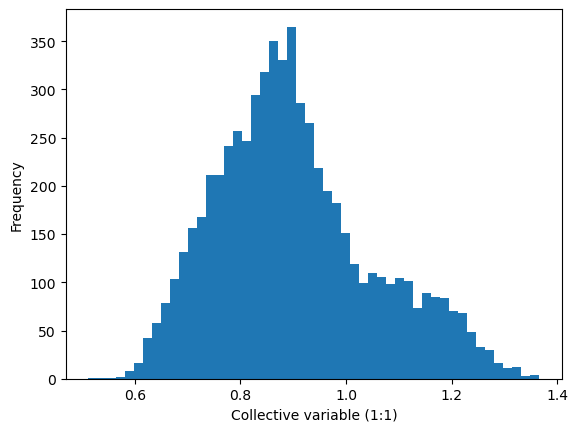

In [229]:
plt.hist(colv0_df["Collective variable (1:1)"], bins=50)
plt.xlabel("Collective variable (1:1)")
plt.ylabel("Frequency")
plt.show()

Ibrahim says the collective variable "`CV(1:1)`" being measured is RMSD (in Angstroms)

In [19]:
sns.set_palette('bright')

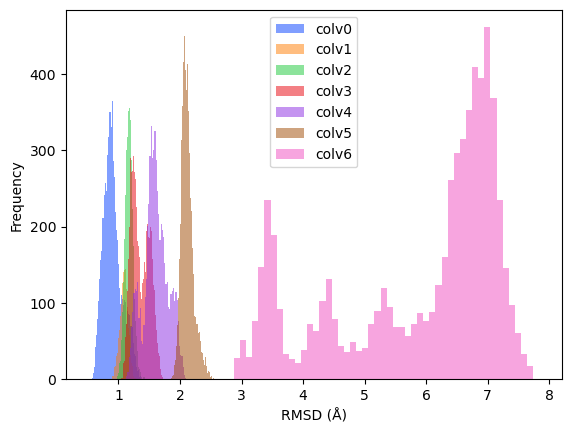

In [20]:
sns.histplot(colv0_df["Collective variable (1:1)"], bins=50, alpha=0.5, label='colv0', edgecolor='none')
sns.histplot(colv1_df["Collective variable (1:1)"], bins=50, alpha=0.5, label='colv1', edgecolor='none')
sns.histplot(colv2_df["Collective variable (1:1)"], bins=50, alpha=0.5, label='colv2', edgecolor='none')
sns.histplot(colv3_df["Collective variable (1:1)"], bins=50, alpha=0.5, label='colv3', edgecolor='none')
sns.histplot(colv4_df["Collective variable (1:1)"], bins=50, alpha=0.5, label='colv4', edgecolor='none')
sns.histplot(colv5_df["Collective variable (1:1)"], bins=50, alpha=0.5, label='colv5', edgecolor='none')
sns.histplot(colv6_df["Collective variable (1:1)"], bins=50, alpha=0.5, label='colv6', edgecolor='none')

plt.xlabel("RMSD (Å)")
plt.ylabel("Frequency")
plt.legend(loc='best')
plt.show()

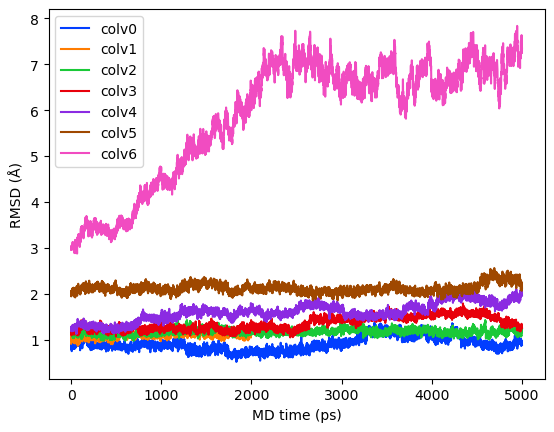

In [21]:
sns.lineplot(data=colv0_df, x="MD time (ps)", y="Collective variable (1:1)", label='colv0')
sns.lineplot(data=colv1_df, x="MD time (ps)", y="Collective variable (1:1)", label='colv1')
sns.lineplot(data=colv2_df, x="MD time (ps)", y="Collective variable (1:1)", label='colv2')
sns.lineplot(data=colv3_df, x="MD time (ps)", y="Collective variable (1:1)", label='colv3')
sns.lineplot(data=colv4_df, x="MD time (ps)", y="Collective variable (1:1)", label='colv4')
sns.lineplot(data=colv5_df, x="MD time (ps)", y="Collective variable (1:1)", label='colv5')
sns.lineplot(data=colv6_df, x="MD time (ps)", y="Collective variable (1:1)", label='colv6')

plt.xlabel("MD time (ps)")
plt.ylabel("RMSD (Å)")
plt.legend(loc='best')
plt.show()

Remove `colv6` as it seems errorneous (evidence bottom of this section)

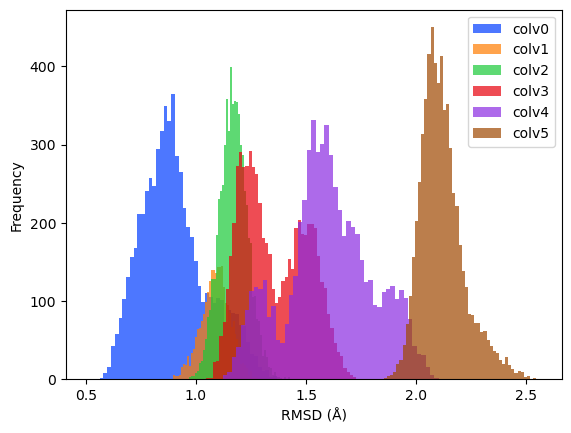

In [56]:
sns.histplot(colv0_df["Collective variable (1:1)"], bins=50, alpha=0.7, label='colv0', edgecolor='none')
sns.histplot(colv1_df["Collective variable (1:1)"], bins=50, alpha=0.7, label='colv1', edgecolor='none')
sns.histplot(colv2_df["Collective variable (1:1)"], bins=50, alpha=0.7, label='colv2', edgecolor='none')
sns.histplot(colv3_df["Collective variable (1:1)"], bins=50, alpha=0.7, label='colv3', edgecolor='none')
sns.histplot(colv4_df["Collective variable (1:1)"], bins=50, alpha=0.7, label='colv4', edgecolor='none')
sns.histplot(colv5_df["Collective variable (1:1)"], bins=50, alpha=0.7, label='colv5', edgecolor='none')

plt.xlabel("RMSD (Å)")
plt.ylabel("Frequency")
plt.legend(loc='best')

plt.savefig("RMSD_hist_o1f2_colv0_5.png", format='png', dpi=300)

plt.show()

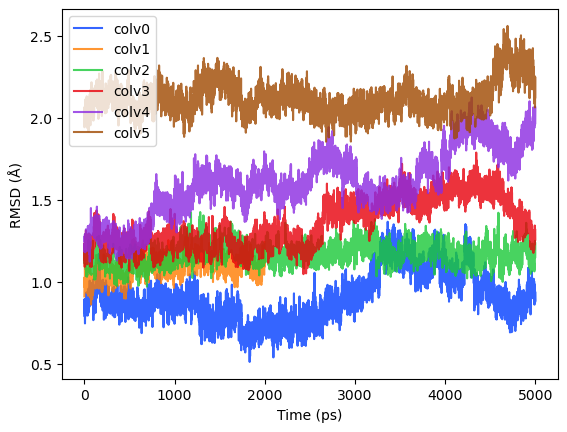

In [55]:
sns.lineplot(data=colv0_df, x="MD time (ps)", y="Collective variable (1:1)", label='colv0', alpha=0.8)
sns.lineplot(data=colv1_df, x="MD time (ps)", y="Collective variable (1:1)", label='colv1', alpha=0.8)
sns.lineplot(data=colv2_df, x="MD time (ps)", y="Collective variable (1:1)", label='colv2', alpha=0.8)
sns.lineplot(data=colv3_df, x="MD time (ps)", y="Collective variable (1:1)", label='colv3', alpha=0.8)
sns.lineplot(data=colv4_df, x="MD time (ps)", y="Collective variable (1:1)", label='colv4', alpha=0.8)
sns.lineplot(data=colv5_df, x="MD time (ps)", y="Collective variable (1:1)", label='colv5', alpha=0.8)

plt.xlabel("Time (ps)")
plt.ylabel("RMSD (Å)")
plt.legend(loc='best')

plt.savefig("RMSD_time_o1f2_colv0_5.png", format='png', dpi=300)

plt.show()

have to check trajectory of simulations (`.prmtop` with `.nc`) in VMD to see why
1. some are bimodal (`colv3` & `colv4`)
2. there are sudden shifts in RMSD (which was intended)\
maybe a drastic conformational change?

NOTE: typo in `mdr7.in`
```in
hier kommentar einfuegen 
 &cntrl 
   imin=0, ntx=5, 
   dielc=1.0, cut=9.0, 
   ntt=1, temp0=300, tautp=2.5, 
   ntp=0, taup=2.5, 
   ntb=1, ntc=2, ntf=2, 
   nstlim=1250000, dt=0.004, 
   ntpr=5000,ntwx=20000,ntwr=5000, 
   infe=1, 
/ 
 &pmd 
   output_file = 'colv6.dat' 
   output_freq = 200 
   cv_file = 'colv7.in' 
/ 
eof 

```
i.e., it overwrote `colv6.dat` when it ended...\
$\rightarrow$ collective variable (RMSD) (which was plotted) is actually from `colv7` run\
which explains the sudden jump...?